<a href="https://colab.research.google.com/github/IsaacFayle-Waters/MLA_Diabetes_with_Notes/blob/main/MLA_CW_2nd_Draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Main Into/Dataset

# Analysis of a Diabetes Dataset With Notes
### Author: Isaac Fayle-Waters.


## Dataset Information
- Title: Diabetes Clinical Dataset(100k rows)
- Source: https://www.kaggle.com/datasets/ziya07/diabetes-clinical-dataset100k-rows


This data is sourced from Kaggle user Ziya, who does not describe the dataset’s origin, instead including the sample size, type of data included, and its intended purpose: predictive modelling (Ziya, 2025). Having an unclear origin is not ideal, so why choose this dataset?

Identifying the patterns of potentially synthesised data provides an additional RQ: Is synthetic generation characterisable?

    

#### Research Questions

- RQ 1: Given four classification models in two groups (Linear / Tree), which performs best during validation?     

- RQ 2: Does feature reduction improve models?

- RQ 3: Does balancing data improve performance?

- RQ 4: Can generic hyperparameters be successfully tuned?  

- RQ 5: How significant are the differences between RQ1’s groups? Or Base and fine-tuned models?

- RQ 6: Can engineered models perform on fresh data? Metrics: F1 and recall?  

- RQ 7: Can creating a third target class of mispredicted false negatives help predict new false negatives?


## Index

>[Analysis of a Diabetes Dataset With Notes](#scrollTo=jB3uEiEeZUI7)

>>>[Author: Isaac Fayle-Waters.](#scrollTo=jB3uEiEeZUI7)

>>[Dataset Information](#scrollTo=jB3uEiEeZUI7)

>>>>[Research Questions](#scrollTo=lFIiOKsq_7OI)

>>>[Diabetes, and the Ethics of Using Synthetic Data in Healthcare](#scrollTo=OofKc0hXsly2)

>>>>[Impact](#scrollTo=OofKc0hXsly2)

>>>>>[Synthetic Data in Healthcare](#scrollTo=OofKc0hXsly2)

>>[Loading Data and Imports](#scrollTo=7JAiMBargy2i)

>>[Functions for EDA and Visualisation](#scrollTo=4DOHgCxhKf54)

>>[Functions for Processing Data](#scrollTo=BTDHfVsym32L)

>>[Metric Functions](#scrollTo=E2fr0JbX8z0r)

>>[EDA:](#scrollTo=0iNA3vxyaYLB)

>>>[Metadata](#scrollTo=S95ZpdJmffym)

>>>>>[Less Obvious Variables](#scrollTo=S95ZpdJmffym)

>>>>>>['hbA1c_level'](#scrollTo=S95ZpdJmffym)

>>>>>>['blood_glucose_level'](#scrollTo=S95ZpdJmffym)

>>>>>>['hypertension'](#scrollTo=S95ZpdJmffym)

>>>>[Continuous Features](#scrollTo=QkPO1NnTTW-v)

>>>>[Categorical Features](#scrollTo=KFr5jFAYT_lw)

>>>>[Discreate Features](#scrollTo=uIiNBEPIUOTY)

>>>>[clinical_notes Preprocessing](#scrollTo=BUs8eoQQ8bZV)

>>>>>[Usage Stats for Individual Sentences](#scrollTo=cuC4z8_FTvDQ)

>>>>[Missing Values From Smoking History](#scrollTo=I-1dzeNDnPwz)

>>>[Visualisations: EDA](#scrollTo=W6-iL3WlE_L2)

>>>>[Count Plots](#scrollTo=3V5wKuIO2-9r)

>>>>[Histograms](#scrollTo=JwxtH_2ASSqE)

>>>>[Correlation Matrix](#scrollTo=G7GNeq_ukdua)

>>>>>[Heatmap and Supportive Stats](#scrollTo=G7GNeq_ukdua)

>>>>>[Co-correlation](#scrollTo=zo_8_v2hcKZk)

>>>>[Pairplot](#scrollTo=86ZviyoGtXqz)

>>>>[Scatter](#scrollTo=VoLbGE069zOi)

>>>>[Density](#scrollTo=JTAzCylN-eea)

>>>>[Box and Violin](#scrollTo=-pXS_sswTyRj)

>>>[Outliers](#scrollTo=f5SSUU7Cp3WB)

>>[Preprocessing](#scrollTo=Yf8HdziDOSas)

>>>[Train, Test, and Validation Data Splits](#scrollTo=yhGVoSsFOwFR)

>>>[Encoding and Scaling](#scrollTo=gl2f_1G0iRlH)

>>>>[Pipelines Defined](#scrollTo=hMXz7EfhzZQX)

>>[RQ 1 : Training Base Models](#scrollTo=TihHIlmS0u71)

>>>>[Linear Models](#scrollTo=TihHIlmS0u71)

>>>>[Tree-Based Ensemble Models](#scrollTo=TihHIlmS0u71)

>>>>>[Timing](#scrollTo=TihHIlmS0u71)

>>>>[Conclusion](#scrollTo=TihHIlmS0u71)

>>>[Model Metrics: Base Models](#scrollTo=425AMeXW5AEd)

>>>>>[Cross-Validation](#scrollTo=PzmqmqRw44Yp)

>>>>[Training Time](#scrollTo=gK0Sp64LOWnM)

>>[RQ 2 : Feature Engineering](#scrollTo=Wc9C1FBR3KdV)

>>>>[Assumptions](#scrollTo=Wc9C1FBR3KdV)

>>>>[Reality](#scrollTo=Wc9C1FBR3KdV)

>>>>[Feature Reduction](#scrollTo=Wc9C1FBR3KdV)

>>>>[Results](#scrollTo=Wc9C1FBR3KdV)

>>>>>[Conclusion](#scrollTo=Wc9C1FBR3KdV)

>>>>[Tuning k Features](#scrollTo=H02aj2ZLR91l)

>>>>[Model Metrics: Feature Engineered](#scrollTo=x4k8XrvG2a8_)

>>>>>[Cross-Validation](#scrollTo=RJtQMeXP4q7z)

>>[RQ 3 : Balenced Data: SMOTE](#scrollTo=4Qe71EQgP4C5)

>>>>>[Results.](#scrollTo=4Qe71EQgP4C5)

>>>>[Conclusion](#scrollTo=4Qe71EQgP4C5)

>>>>[Metrics and Pipeline](#scrollTo=emQbLV1ZiXwQ)

>>>>>[Sampling Strategy Tuning Attempt](#scrollTo=iEcnW20R6llk)

>>>>>[Cross-Validation](#scrollTo=t1fVf3SLSJju)

>>[RQ 4: Hyperparameter Tuning](#scrollTo=MYmzA57UkNTo)

>>>>>[Methodology:](#scrollTo=MYmzA57UkNTo)

>>>>>[Removing SVC and Base Models](#scrollTo=MYmzA57UkNTo)

>>>>[Fine Tuning](#scrollTo=MYmzA57UkNTo)

>>>>>[Results](#scrollTo=MYmzA57UkNTo)

>>>>[Conclusion](#scrollTo=MYmzA57UkNTo)

>>>>>[Base GridCV Tuning](#scrollTo=Bug7huLRqeoA)

>>>>[Fine Tuning](#scrollTo=AImv6wGpNjhK)

>>>>>[Significance Test : Logistic Regression](#scrollTo=dbUM-v_nkSya)

>>>>>[Fine Tuning Feature Selected](#scrollTo=lVcK8tfjkjkD)

>>>[Model Metrics: Tuned Hyperparameters](#scrollTo=rX8bEmLyXDj2)

>>>[Cross-Validation](#scrollTo=PSa4Cg9BafR9)

>>[RQ 5 : Overall and Significance](#scrollTo=3vmP4U8ccqIw)

>>>>>[Overall Comparison Reveals:](#scrollTo=3vmP4U8ccqIw)

>>>>[Significance Testing](#scrollTo=3vmP4U8ccqIw)

>>>>[Conclusion](#scrollTo=3vmP4U8ccqIw)

>>>>[Full Model CV Comparison](#scrollTo=2uYSevSUuXlR)

>>>>[Significance Tests: Tree vs Linear](#scrollTo=tzUa1EmOJvOC)

>>>>[Significance Test: Base vs Fine Tuned and Feature Selected](#scrollTo=L_UOcI31PL29)

>>[RQ 6 : Final Analysis on Test Set](#scrollTo=Qz3tT1nBTswF)

>>>>[Results](#scrollTo=Qz3tT1nBTswF)

>>[RQ 7 : Recall Set Experiment](#scrollTo=sQMWOLGLc3ea)

>>>>>[Methodology](#scrollTo=sQMWOLGLc3ea)

>>>[Results](#scrollTo=sQMWOLGLc3ea)

>>>>[Conclusion](#scrollTo=sQMWOLGLc3ea)

>>[Reflection](#scrollTo=NfnMNCttFOV2)

>>[References](#scrollTo=uPh7k_2aFZJS)

>>[APPENDIX](#scrollTo=2ZP1B3A6GnZo)

>>>[A. List of Claude.ai conversations used in this project.](#scrollTo=2ZP1B3A6GnZo)



### Diabetes, and the Ethics of Using Synthetic Data in Healthcare

#### Impact

Diabetes impacts and potentially kills millions of people worldwide every year. Complications from diabetes can lead to other illnesses, particularly cardiovascular. Diabetes is a source of anxiety, meaning daily medical checks for many sufferers, and usually strict diet control (K.M.Venkat Narayan et al., 2011, p. 3), (Egan and Dinneen, 2019).

##### Synthetic Data in Healthcare

Generating fake data about healthcare could appear dangerous and unethical if used to exploit people’s medical needs, but there are benefits. Healthcare data is notoriously hard to source: it contains private personal insights. But models need data to learn from, and their authors need experience in dealing with the data and terminology common to medicine. Synthetic data helps to fill this gap by offering resources to researchers and increased privacy protection to patients (Gonzales, Guruswamy and Smith, 2023).

## Loading Data and Imports



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#General Base Imports
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

#Data Processing Imports
import spacy
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

#Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

#Metrics
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel
from sklearn.metrics import roc_curve, auc


In [ ]:
#Begin environment
#Create two dataframes containing the data: `df_raw` is a base copy of raw data that won't be altered; `df` is the dataset we will work with. (This follows Haixia's process in 'StudentID_Haixia_Titanic.ipynb')
df_raw =  pd.read_csv('/content/drive/MyDrive/Uni-Masters/MLA/Project_Second_Draft/Data/diabetes_dataset_with_notes.csv')
df = df_raw.copy()

In [ ]:
#Environment Control
SEED = 42 # Seed set to ensure reproducability

CV_TEST = 3 # Cut time during set-uo
CV_FULL = 5 # For full runs
CV_DEFINED = CV_FULL #SETS CURRENT MODE

SCORE_STRING = 'f1_macro'#Better for imbalenced data, as doesn't let bigger class dominate

warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
pd.options.display.max_rows = None
%matplotlib inline

In [ ]:
#Graph aesthetics Adjustments

#Style parameters with help fromm claude.ai
#Colourblind friendly palette (Okabe-Ito palette)
okabe_Ito_palette = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]#["#2C5F7C", "#8B4789", "#C17E5D", "#5B8266", "#7A5C61"]
#sns.set_palette(okabe_Ito_palette)
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = '#fafafa'#off-white background
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#e8e8e8'
plt.rcParams['axes.edgecolor'] = '#8b7ba8'#purple border

## Functions for EDA and Visualisation


In [ ]:
def val_count_vis(df: pd.DataFrame = None, target: str = '', title: str = '') -> None:
    '''
    Parameters: `DataFrame`, `str`, `str`

    Description: Graphic equivelant of `.value_counts()`.
    *Some tweaks/functionality from claude.ai
    '''
    fig, ax = plt.subplots()
    sns.countplot(data=df, x=target, ax=ax, hue=target, palette=okabe_Ito_palette)
    ax.set_title(title)
    for container in ax.containers:
        ax.bar_label(container)

    plt.show()

In [ ]:
def count_plots_cat_cols(df: pd.DataFrame = None, title: str = '') -> None:
    '''
    Parameters: `DataFrame`, `str`

    Description: Creates subplots of count plots for all categorical columns in the dataframe.
    *Asked claude.ai to rewrite val_count_vis for categorical data -> this function
    '''
    cols = df.columns
    n_cols = len(cols)

    # Calculate grid dimensions
    n_rows = (n_cols + 2) // 3  # 3 columns per row
    n_subplot_cols = min(n_cols, 3)

    fig, axes = plt.subplots(n_rows, n_subplot_cols, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)

    # Flatten axes array for easier indexing
    if n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_cols > 3 else axes

    for idx, col in enumerate(cols):
        sns.countplot(data=df, x=col, ax=axes[idx], hue=col, palette=okabe_Ito_palette, legend=False)
        axes[idx].set_title(col)
        for container in axes[idx].containers:
            axes[idx].bar_label(container)

    # Hide empty subplots if any
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
def num_plots_hist_den(df: pd.DataFrame = None, title: str = '', plot_type: str = 'hist', bins: int = 40) -> None:
    '''
    Parameters: `DataFrame`, `str`, `str`

    Description: Creates subplots of distributions for all numerical columns.
    plot_type: 'hist' for histogram or 'kde' for kernel density estimate
    *Based on 'count_plots_cat_cols', but asked for specific changes from
    claude.ai, then taylored to support `blood_glucose_level` and `years`
    '''
    cols = df.columns
    n_cols = len(cols)

    # Calculate grid dimensions
    n_rows = (n_cols + 2) // 3  # 3 columns per row
    n_subplot_cols = min(n_cols, 3)

    fig, axes = plt.subplots(n_rows, n_subplot_cols, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)

    # Flatten axes array for easier indexing
    if n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_cols > 3 else axes

    for idx, col in enumerate(cols):
        # Check if binary/bivariate
        n_unique = df[col].nunique()

        if plot_type == 'kde':
            sns.kdeplot(data=df, x=col, ax=axes[idx], fill=True, color=okabe_Ito_palette[0])
        else:  # histogram
            if n_unique == 2:
                # Binary data - use exactly 2 bins
                sns.histplot(data=df, x=col, ax=axes[idx], color=okabe_Ito_palette[0], kde=False, bins=2, discrete=True)
                axes[idx].set_xticks([0, 1])
            # Non-binary discrete/continuous data
            else:
                sns.histplot(data=df, x=col, ax=axes[idx], color=okabe_Ito_palette[0], kde=False , bins=bins)

            # Add count labels on bars
            for container in axes[idx].containers:
                axes[idx].bar_label(container)

        axes[idx].set_title(col)

    # Hide empty subplots if any
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
def dtype_corr(corr: pd.DataFrame = None, title: str = '' ) -> None:
  '''
  Parameters: `DataFrame`, `str`
  Description: Produces a little Heatmap, for use with groups features
  *claud.ai adapted the padding and rotate labels
  '''
  mask = np.triu(np.ones_like(corr, dtype=bool))
  fig, ax = plt.subplots(figsize=(8,6))
  cmap = sns.diverging_palette(230,20,as_cmap=True)
  sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
              square=True, linewidths=.5, cbar_kws={"shrink" : .5},
              annot=True, fmt='.2f')

  #Rotate label
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)

  #padding
  plt.title(title)
  plt.tight_layout()
  plt.show()


In [ ]:
def distribution_by_diabetes(df: pd.DataFrame = None, feature: str = '', title: str = '') -> None:
    '''
    Parameters: `DataFrame`, `str`, `str`

    Description: Shows KDE distribution of a feature split by diabetes status.
    *Generated by claude.ai, on request
    '''
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(data=df[df['diabetes']==0], x=feature, fill=True,
                color=okabe_Ito_palette[0], label='No Diabetes', alpha=0.5, ax=ax)
    sns.kdeplot(data=df[df['diabetes']==1], x=feature, fill=True,
                color=okabe_Ito_palette[4], label='Has Diabetes', alpha=0.5, ax=ax)
    ax.set_title(title)
    ax.legend()
    plt.show()

In [ ]:
def cat_plot_by_diabetes(
    df: pd.DataFrame = None,
    x_target: str = '',
    y_target: str = '',
    plt_type: str = 'box',
    title: str = '') -> None:
    '''
    Parameters: pd.DataFrame, str, str, str, str
    Description: Catagory Plotting, hue represents diabetes
    *chatGPT origin
    '''

    sns.catplot(
        df,
        x=x_target,
        y=y_target,
        hue='diabetes',
        kind=plt_type,
        palette=[okabe_Ito_palette[0], okabe_Ito_palette[4]])

    plt.title(title)
    plt.show()

In [ ]:
def mean_target(df: pd.DataFrame = None,
                target: str = '',
                plt_type: str = 'violin',
                lines: bool = True) -> None:
  '''
  Parameters: pd.DataFrame, str, str
  Description: Box and violin plots of any target variable specified. Labels them with bottom .05
  and upper .05 quantiles. Also mean.
  '''
  if plt_type == 'violin':
    sns.violinplot(df, x=target, color=okabe_Ito_palette[0])
  elif plt_type == 'box':
    sns.boxplot(df, x=target, color=okabe_Ito_palette[0])
  else:
    return None
  if lines == True:
    mean_target = df[target].mean()
    quants = df[target].quantile([.05, .25, .5, .75, .95])
    quart_lower = quants.values[0]
    quart_upper = quants.values[4]
    #Plot lines
    plt.axvline(quart_lower , color='blue', linestyle='--', linewidth=2, label=f'5% data lower than: {quart_lower:.2f}')
    plt.axvline(mean_target, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_target:.2f}')
    plt.axvline(quart_upper , color='red', linestyle='--', linewidth=2, label=f'5% data higher than: {quart_upper:.2f}')
    plt.legend(loc='lower right')

  plt.title(target)
  plt.show()


In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name='Model'):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    divergence = sns.diverging_palette(230,20,as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

## Functions for Processing Data

In [ ]:
def clin_notes_encode(df:pd.DataFrame) -> pd.DataFrame :
  '''
  ## `clin_notes_encode`
  ### Parameters: DataFrame
  ### Returns: Dataframe

  ### Description: Encodes `clinical_notes` features, by extracting each semtence
  and including it in a DataFrame as a non-excluse feature, similar to a
  multi-label binarizer.


*claud.ai usage
Claude.ai gave this to me without my asking :( Though it is exactly what I had in
mind to create next. I beleive this is because it was the logical next step.
https://claude.ai/share/8f394c0a-5c5f-42c5-9b53-a8e7a222e3cb
  '''
  df_with_clin_notes = df
  for i, sentence in enumerate(sentence_counts.index):
      feature_name = f'has_sentence_{i}'  # or use a descriptive name
      df_with_clin_notes[feature_name] = df['clinical_notes'].str.contains(sentence, regex=False).astype(int)

  return df_with_clin_notes


In [ ]:
def plot_recall_by_k_features(pipe, X_train, y_train, X_val, y_val, max_k =89, plot = True):
    """
    Test different numbers of features (k) and plot recall scores.

    Parameters:
    -----------
    pipe : sklearn Pipeline
        Pipeline with 'preprocessor' and 'model' steps
    X_train, y_train : training data
    X_val, y_val : validation data
    max_k : int, maximum number of features to test (default 89)

    Returns:
    --------
    best_k : int, number of features that gave best recall
    best_recall : float, best recall score achieved

    *Requested function from claude.ai to be created to re-use my own code
    """
    recall_scores = []

    for k in range(1, max_k):
        # Create pipeline with feature selection
        feature_select_pipe = Pipeline([
            ('preprocessor', pipe.named_steps['preprocessor']),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k)),
            ('model', pipe.named_steps['model'])
        ])

        # Train and evaluate
        feature_select_pipe.fit(X_train, y_train)
        y_pred = feature_select_pipe.predict(X_val)
        recall = recall_score(y_val, y_pred)
        recall_scores.append(recall)

    if plot == True:
        plt.plot(recall_scores)
        best_recall = max(recall_scores)
        best_k = recall_scores.index(best_recall) + 1
        plt.title(f'Recall vs K Features: MAX {best_recall:.3f} @ k={best_k}')
        plt.xlabel('K Features')
        plt.ylabel('Recall')
        plt.show()

    return best_k, best_recall


## Metric Functions

In [ ]:
def basic_scores(X_validation, y_validation, pipe, model_name):
  '''Description: Simple little function for calculating reports and scores '''
  y_pred = pipe.predict(X_validation)
  print(classification_report(y_validation, y_pred))
  print(f"Recall : {recall_score(y_validation, y_pred)}")
  plot_confusion_matrix(y_validation, y_pred, model_name=model_name)

## EDA:


### Metadata

`Diabetes_dataset_with_notes.csv`: 100,000 samples, spread across 17 features. The data includes a mixture of data types: 10 integer (`int64`), 4 `object`, and 3 floating point columns (`float64`).

A check of missing data, using `.isna(),` reveals no obviously empty cells.

Five features contain the prefix 'race', followed by a descriptor of a racial grouping, characteristic of racial categories used in the USA. Their naming and representation (`0 0 0 0 1`,  `0 0 1 0 0`) suggest previous one-hot encoding, hinting at obfuscation rather than generation.

##### Less Obvious Variables

###### *`'hbA1c_level'`*

HbA1c levels over 48 mmol/mol are consistent with diabetes. HBA1c provides a measure of blood sugar over a 2-3 month period (Egan and Dinneen, 2019).

In the USA, this measurement is taken as a percentage of glycated red blood cells (Panchal, 2024):, 6.5% being equal to 48 mmol/mol (Accu-Chek UK & Ireland, 2023).

###### *`'blood_glucose_level'`*

Blood sugar daily/hourly range.

Normal levels are between 70 mg/dL and 99 mg/dL in the US (Selph, 2023).

###### *`'hypertension'`*

High blood pressure of at least 140/90 mmHg" (Balkau et al., 2008). Hypertension is associated with insulin resistance (Egan and Dinneen, 2019), and a variety of factors that might contribute to diabetic positivity (Balkau et al., 2008).


In [ ]:
print(f"Shape of data = {df.shape}. Rows = {df.shape[0]}, columns = {df.shape[1]}.")

Shape of data = (100000, 17). Rows = 100000, columns = 17.


In [ ]:
print(f'Details of missing data : {df.isna().sum().sum()}')

Details of missing data : 0


In [ ]:
#Datatypes amd columns by type
print('_'*150)
print(f"Data Types:\n\n {df.dtypes.value_counts()}\n")
print('_'*150)
print('Coulmns by datatype:\n')
print('--'*125)
print(f"Floating Point : {df.select_dtypes(include='float64').columns}")# snippet from claude.ai
print('--'*125)
print(f"Object : {df.select_dtypes(include='object').columns}")
print('--'*125)
print(f"Integer : {df.select_dtypes(include='int64').columns}")



______________________________________________________________________________________________________________________________________________________
Data Types:

 int64      10
object      4
float64     3
Name: count, dtype: int64

______________________________________________________________________________________________________________________________________________________
Coulmns by datatype:

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Floating Point : Index(['age', 'bmi', 'hbA1c_level'], dtype='object')
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Object : Index(['gend

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [ ]:
print(f'Column names:\n {df.columns.values}')

Column names:
 ['year' 'gender' 'age' 'location' 'race:AfricanAmerican' 'race:Asian'
 'race:Caucasian' 'race:Hispanic' 'race:Other' 'hypertension'
 'heart_disease' 'smoking_history' 'bmi' 'hbA1c_level'
 'blood_glucose_level' 'diabetes' 'clinical_notes']


In [ ]:
#Show random(ish) sample of the data
df.sample(n=5, random_state=SEED)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
75721,2019,Female,80.0,Oklahoma,1,0,0,0,0,0,1,current,17.01,4.8,200,0,Elderly patient with increased risk of chronic...
80184,2019,Female,25.0,Pennsylvania,0,1,0,0,0,0,0,never,48.35,6.5,145,0,"Obese category, increased risk for diabetes an..."
19864,2019,Female,33.0,Florida,1,0,0,0,0,1,0,ever,36.70,6.8,145,1,"Obese category, increased risk for diabetes an..."
76699,2019,Female,80.0,Oregon,0,0,0,0,1,0,0,No Info,27.32,4.5,100,0,Elderly patient with increased risk of chronic...
92991,2019,Female,80.0,Utah,0,1,0,0,0,0,0,not current,24.30,4.0,100,0,Elderly patient with increased risk of chronic...


#### Continuous Features

In [ ]:
continuous_features = df.select_dtypes(include='float64')
#continuous_features['blood_glucose_level'] = df['blood_glucose_level']
continuous_features.sample(3, random_state=SEED)

,age,bmi,hbA1c_level
75721,80.0,17.01,4.8
80184,25.0,48.35,6.5
19864,33.0,36.70,6.8


In [ ]:
continuous_features.describe()

,age,bmi,hbA1c_level
count,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507
std,22.516840,6.636783,1.070672
min,0.080000,10.010000,3.500000
25%,24.000000,23.630000,4.800000
50%,43.000000,27.320000,5.800000
75%,60.000000,29.580000,6.200000
max,80.000000,95.690000,9.000000


In [ ]:
#Unique values by age, showing mostly rounded 'integer style' entries for adults,
#and more prceise, real numbers for toddlers/under twos
print('_'*150)
print('UNIQUE AGES')
np.sort(df.age.unique())

______________________________________________________________________________________________________________________________________________________
UNIQUE AGES


array([ 0.08,  0.16,  0.24,  0.32,  0.4 ,  0.48,  0.56,  0.64,  0.72,
        0.8 ,  0.88,  1.  ,  1.08,  1.16,  1.24,  1.32,  1.4 ,  1.48,
        1.56,  1.64,  1.72,  1.8 ,  1.88,  2.  ,  3.  ,  4.  ,  5.  ,
        6.  ,  7.  ,  8.  ,  9.  , 10.  , 11.  , 12.  , 13.  , 14.  ,
       15.  , 16.  , 17.  , 18.  , 19.  , 20.  , 21.  , 22.  , 23.  ,
       24.  , 25.  , 26.  , 27.  , 28.  , 29.  , 30.  , 31.  , 32.  ,
       33.  , 34.  , 35.  , 36.  , 37.  , 38.  , 39.  , 40.  , 41.  ,
       42.  , 43.  , 44.  , 45.  , 46.  , 47.  , 48.  , 49.  , 50.  ,
       51.  , 52.  , 53.  , 54.  , 55.  , 56.  , 57.  , 58.  , 59.  ,
       60.  , 61.  , 62.  , 63.  , 64.  , 65.  , 66.  , 67.  , 68.  ,
       69.  , 70.  , 71.  , 72.  , 73.  , 74.  , 75.  , 76.  , 77.  ,
       78.  , 79.  , 80.  ])

#### Categorical Features

In [ ]:
categorical_features = df.select_dtypes(include='object')
categorical_features.head()

,gender,location,smoking_history,clinical_notes
0,Female,Alabama,never,"Overweight, advised dietary and exercise modif..."
1,Female,Alabama,never,Healthy BMI range.
2,Male,Alabama,never,"Young patient, generally lower risk but needs ..."
3,Male,Alabama,never,"Overweight, advised dietary and exercise modif..."
4,Female,Alabama,never,"Healthy BMI range. High HbA1c level, indicativ..."


In [ ]:
categorical_features.describe()

,gender,location,smoking_history,clinical_notes
count,100000,100000,100000,100000
unique,3,55,6,761
top,Female,Kentucky,No Info,"Overweight, advised dietary and exercise modif..."
freq,58552,2038,35816,4650


#### Discreate Features

In [ ]:
discreate_features = df.select_dtypes(include='int64')
#discreate_features = discreate_features[discreate_features.columns.difference(['blood_glucose_level'])]
discreate_features.head()

,year,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,blood_glucose_level,diabetes
0,2020,0,0,0,0,1,0,0,100,0
1,2015,0,1,0,0,0,0,0,90,0
2,2015,0,0,0,0,1,0,0,160,0
3,2015,0,0,1,0,0,0,0,159,0
4,2016,1,0,0,0,0,0,0,90,0


In [ ]:
#Need to remove race specific columns for better readability
race_cols = df.columns[df.columns.str.contains('race')]#Courtasy of claude.ai
non_race_discreate_features = discreate_features[discreate_features.columns.difference(race_cols)]
non_race_discreate_features.sample(n=5,random_state=SEED)

,blood_glucose_level,diabetes,heart_disease,hypertension,year
75721,200,0,1,0,2019
80184,145,0,0,0,2019
19864,145,1,0,1,2019
76699,100,0,0,0,2019
92991,100,0,0,0,2019


In [ ]:
non_race_discreate_features[['blood_glucose_level', 'year']].describe() # Other features are binary

,blood_glucose_level,year
count,100000.000000,100000.000000
mean,138.058060,2018.360820
std,40.708136,1.345239
min,80.000000,2015.000000
25%,100.000000,2019.000000
50%,140.000000,2019.000000
75%,159.000000,2019.000000
max,300.000000,2022.000000


In [ ]:
df[race_cols].sum()

,0
race:AfricanAmerican,20223
race:Asian,20015
race:Caucasian,19876
race:Hispanic,19888
race:Other,19998


#### `clinical_notes` Preprocessing

This feature consists of multiple repeated sentences in 761 unique combinations across the 100,000 sample.These are extracted and encoded using a custom method.

Given ambiguous origins, it is important to ensure sentence meanings align with other information within samples:

Sentence 11, "Young patient, generally lower risk but needs lifestyle assessment", is included for 25.9% of the population, but only 0.6% of the time for positive samples.

Sentence 2, "High HbA1c level, indicative of diabetes or poor glucose control", is included in 25% of positive diagnoses, while making up 20.8% of all sentences used.

This pattern continues.








In [ ]:
nlp = spacy.load('en_core_web_sm')
#*NLP code is the result of back and forth with claude.ai - https://claude.ai/share/8f394c0a-5c5f-42c5-9b53-a8e7a222e3cb

In [ ]:
#Get a list of the unique sentences used.
individual_sentences = []
#Get each unique string from `clinical_notes`, then use spacy to extract each
#sentence from each individual string
for note in df.clinical_notes.unique():
  doc = nlp(note)
  for sentence in doc.sents:
    individual_sentences.append(sentence.text.strip())

In [ ]:
#Convert to Series for easy manipulation
sentence_counts = pd.Series(individual_sentences).value_counts()

In [ ]:
#Full list
for i, sentence in enumerate(sentence_counts.index):
  print(f'{i}: {sentence}')

0: History of smoking, potential lung and vascular health impact.
1: Elevated blood glucose levels, potential diabetes concern.
2: High HbA1c level, indicative of diabetes or poor glucose control.
3: Elderly patient with increased risk of chronic conditions.
4: History of hypertension, monitor blood pressure regularly.
5: Cardiac condition present, high cardiovascular risk.
6: Higher predisposition to hypertension and diabetes.
7: Consideration for metabolic syndrome and Type 2 diabetes.
8: Obese category, increased risk for diabetes and cardiovascular disease.
9: Overweight, advised dietary and exercise modifications.
10: Healthy BMI range.
11: Young patient, generally lower risk but needs lifestyle assessment.
12: Underweight, potential nutritional deficiencies.


In [ ]:
#Split data, positive/negative
df_with_diabetes = df[df.diabetes == 1]
df_without_diabetes = df[df.diabetes == 0]

#Counts and lists For later comparison

#Just those with positive diagnoses
sentence_used_with = []
total_wi = 0
#All rows
sentence_used_all = []
total = 0
#Negative
total_neg = 0
sentnece_used_negative = []

#Collect sentence usage data for comparison
for i,sentence in enumerate(sentence_counts.index):
  #Positive
  usage_wi = df_with_diabetes.clinical_notes.str.contains(sentence).sum()
  total_wi += usage_wi
  sentence_used_with.append(usage_wi)

  #Negative
  usage_neg = df_without_diabetes.clinical_notes.str.contains(sentence).sum()
  total_neg += usage_neg
  sentnece_used_negative.append(usage_neg)

  #All
  usage = df.clinical_notes.str.contains(sentence).sum()
  sentence_used_all.append(usage)
  total += usage


##### Usage Stats for Individual Sentences
  

In [ ]:
#SENTENCE INCLUSION stats FOR POSITIVE DIAGNOSIS
'''Usage stats for each sentence. Includes proportions relative to diagnosis,
total sentence usage, and usage relative to the total number of samples. '''
for i, sentence in enumerate(sentence_counts.index):
  all = sentence_used_all[i]
  yes = sentence_used_with[i]
  no = sentnece_used_negative[i]
  perc_yes = ((yes/all) * 100)
  perc_no = ((no/all) * 100)
  total_inclusion_perc = ((all/len(df)) * 100)

  print(f'Sentence {i} : "{sentence}"')
  print(f"Count for every time used : {all}")
  print(f"Count for used when diabetes present : {yes}")
  print(f"Count for used when diabetes NOT present : {no}")
  print('-----------------------%%%------------------------')
  print(f"Percentage of inclusion with POSITIVE diagnosis {perc_yes:.2f}%")
  print(f"Percentage of inclusion with NEGATIVE diagnosis {perc_no:.2f}%")
  print(f'Total Inclusion Percentage {total_inclusion_perc:.2f}%')
  print('--'*75)

Sentence 0 : "History of smoking, potential lung and vascular health impact."
Count for every time used : 64905
Count for used when diabetes present : 5154
Count for used when diabetes NOT present : 59751
-----------------------%%%------------------------
Percentage of inclusion with POSITIVE diagnosis 7.94%
Percentage of inclusion with NEGATIVE diagnosis 92.06%
Total Inclusion Percentage 64.91%
------------------------------------------------------------------------------------------------------------------------------------------------------
Sentence 1 : "Elevated blood glucose levels, potential diabetes concern."
Count for every time used : 64154
Count for used when diabetes present : 7864
Count for used when diabetes NOT present : 56290
-----------------------%%%------------------------
Percentage of inclusion with POSITIVE diagnosis 12.26%
Percentage of inclusion with NEGATIVE diagnosis 87.74%
Total Inclusion Percentage 64.15%
------------------------------------------------------

In [ ]:
#KEEP?
print(f'Number of times each sentence used for all samples: {total:,} ')
print(f'''Number of times each sentence used for samples with positive diagnoses: {total_wi:,}  ''')
print(f'Sentences usage per diabetes positive cases {(total_wi / total) * 100:.2f}%')
print(f"Total positive diagnosed as percentage of total {(len(df_with_diabetes) / len(df))*100:.2f}%")

Number of times each sentence used for all samples: 350,911 
Number of times each sentence used for samples with positive diagnoses: 38,382  
Sentences usage per diabetes positive cases 10.94%
Total positive diagnosed as percentage of total 8.50%


#### Missing Values From Smoking History
The largest class in `smoking_history` is ‘No Info’, as seen in the `smoking_history` countplot, where the number of 'No Info' entries = 35,816.   

As shown in the previous section, Sentence 0 extracted from `clinical_notes` reads: "History of smoking, potential lung and vascular health impact". Shown below are the value counts for all samples that contain Sentence 0: this is also = 35,816.

Therefore, every sample assigned 'No Info' for `smoking_history` also contains 'Sentence 0' ("history of smoking...").

As there is no further indication as to their *current* smoking status, the value 'ever' will be assigned to the ‘No Info’  rows, rather than dropping columns or rows entirely. The effects of this can be seen in the count plots    

In [ ]:
df_with_clin_notes = clin_notes_encode(df)

In [ ]:
#Value counts of data where Sentence 0 (history of smoking) is included.
df_other = df_with_clin_notes[df_with_clin_notes.location.str.contains('United')]
df_other[race_cols].sum()

,0
race:AfricanAmerican,299
race:Asian,279
race:Caucasian,272
race:Hispanic,278
race:Other,273


In [ ]:
1#
#VALUE COUNTS OF THE SMOKING HISTORY OF THOSE DATA WHERE THE SENTENCE
#'History of smoking...' IS PRESENT
df_hist_of_smoke = df_with_clin_notes[df_with_clin_notes.has_sentence_0 == 1]
df_hist_of_smoke['smoking_history'].value_counts()

,count
smoking_history,
No Info,35816
former,9352
current,9286
not current,6447
ever,4004


In [ ]:
#2
#ALL SMOKING HISTORY
df.smoking_history.value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


In [ ]:
df_smoking_replaced = df.replace('No Info','ever')
df_smoking_replaced['smoking_history'].unique()

array(['never', 'not current', 'current', 'ever', 'former'], dtype=object)

### Visualisations: EDA

#### Count Plots

 `gender` displays a class imbalance. An underrepresented third category of 'other' makes up 0.018% of the data, not reflecting the percentage of people identifying as non-binary within the US: 2.65% (USA Facts Team, 2023). The `race:x` features show an even spread

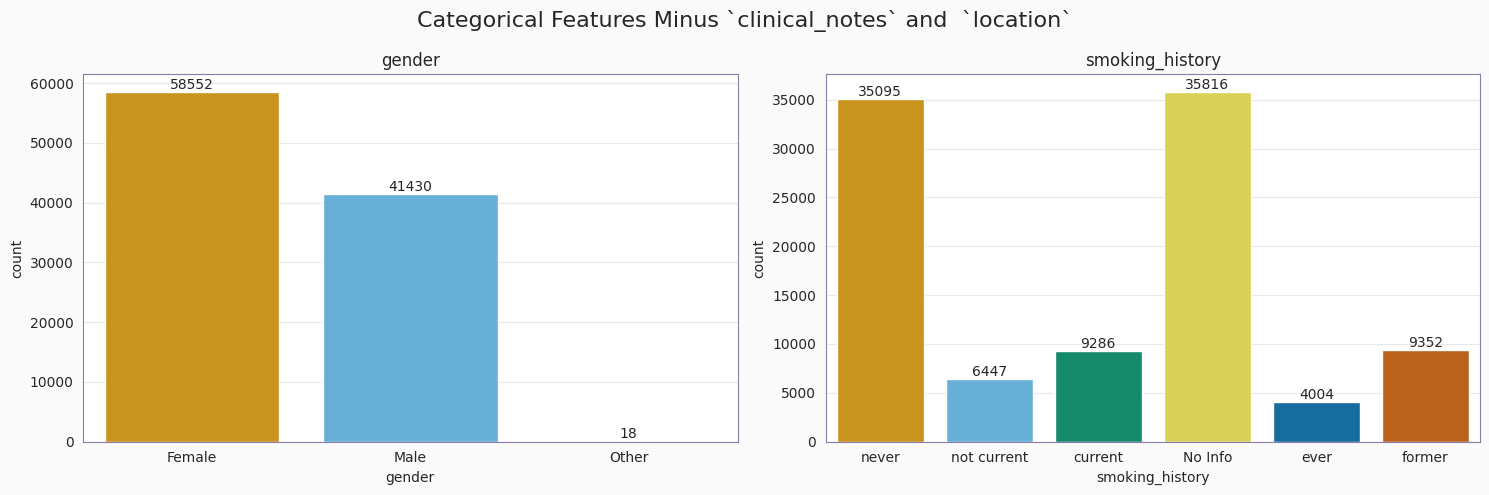

In [ ]:
cat_no_notes_location =categorical_features[categorical_features.columns.difference(['clinical_notes', 'location'])]
count_plots_cat_cols(cat_no_notes_location, 'Categorical Features Minus `clinical_notes` and  `location`')

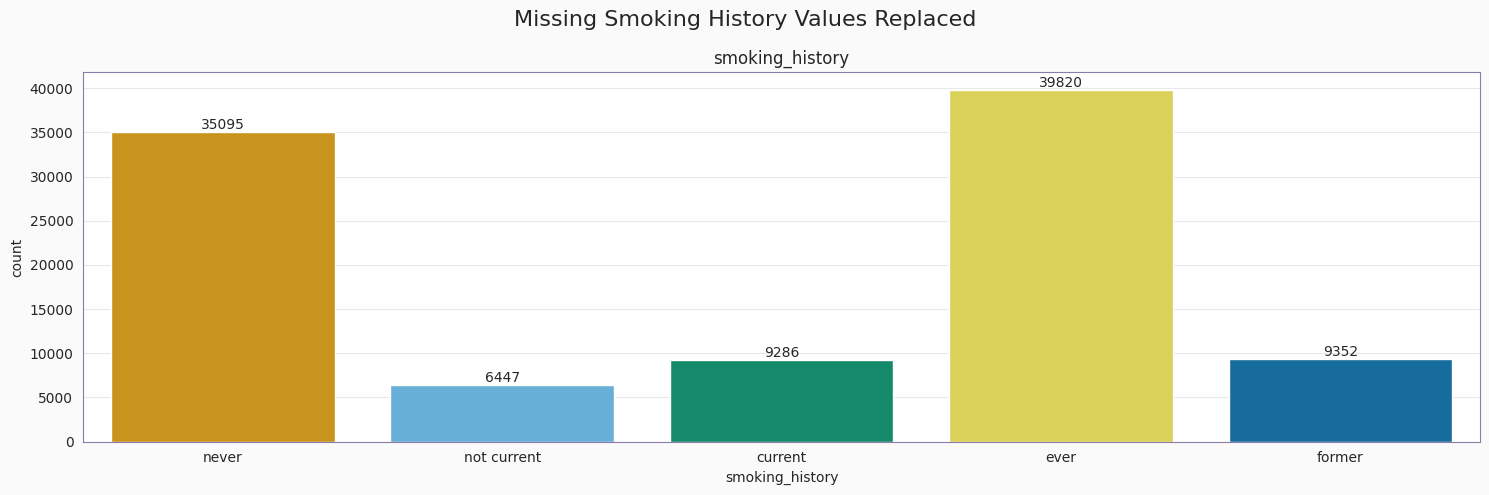

In [ ]:
count_plots_cat_cols(df_smoking_replaced[['smoking_history']], title='Missing Smoking History Values Replaced')

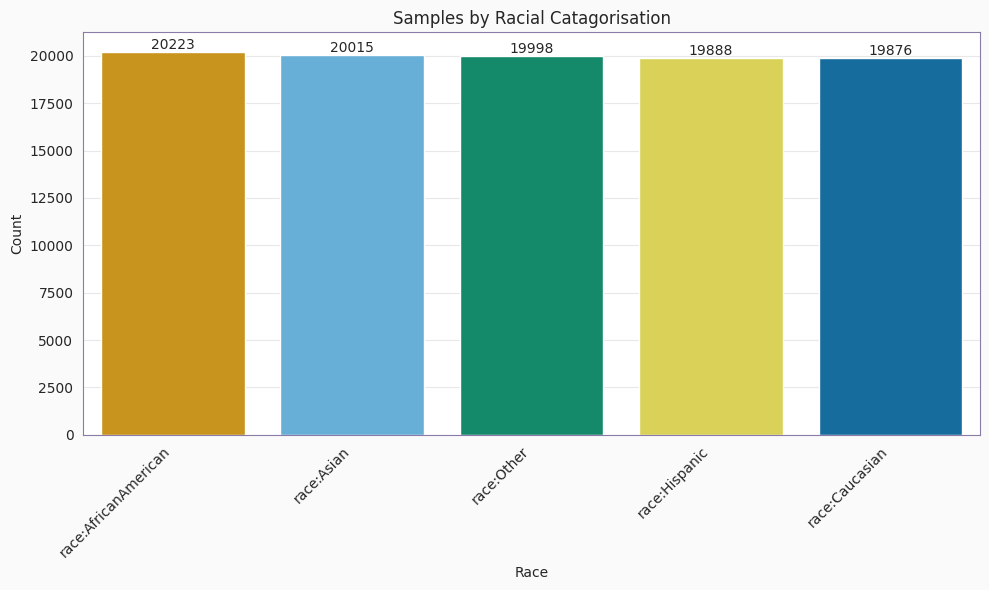

In [ ]:
#I don't remember writing this, so probably generated
race_counts = df[race_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=race_counts.index, y=race_counts.values, palette=okabe_Ito_palette)
for i, v in enumerate(race_counts.values):
    ax.text(i, v, str(int(v)), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Race')
plt.ylabel('Count')
plt.title('Samples by Racial Catagorisation')
plt.tight_layout()
plt.show()

#### Histograms

The diabetes graphs show target imbalance: diabetes positivity accounts for only 8.5% of the data. Similar distributions are seen for heart_disease and hypertension, while year shows that just under 80% of the data is represented as having been recorded in 2019.

`blood_glucose_level` looks trimodal, showing that less than a third of the data is below 100 mg/dl, corroborated by a mean of 138 mg/dl, and the lower quantile at 100. There are also some extremely high readings around 300 mg/dl. These could suggest three groups: low risk, pre-diabetic, and diabetic.

`location`’s histogram shows little variation in diabetes prevalence between states, except for variation explained by population differences.
   

0.25    100.0
0.50    140.0
0.75    159.0
Name: blood_glucose_level, dtype: float64


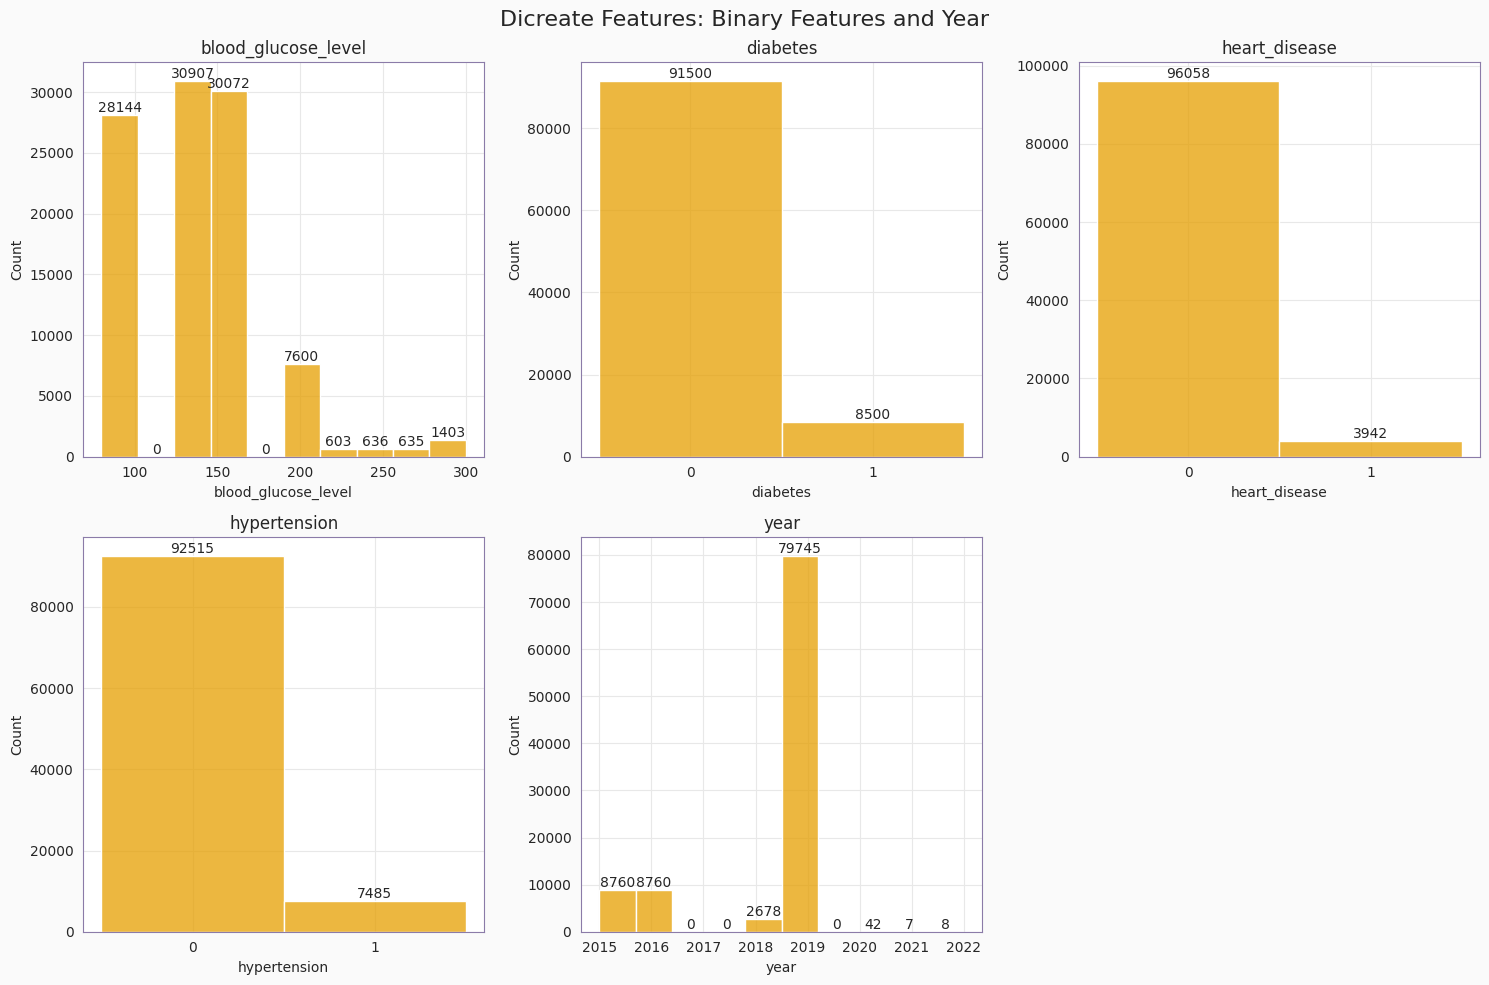

In [ ]:
print(df.blood_glucose_level.quantile([.25, .5, .75]))
num_plots_hist_den(non_race_discreate_features, title='Dicreate Features: Binary Features and Year', plot_type='hist', bins=10)

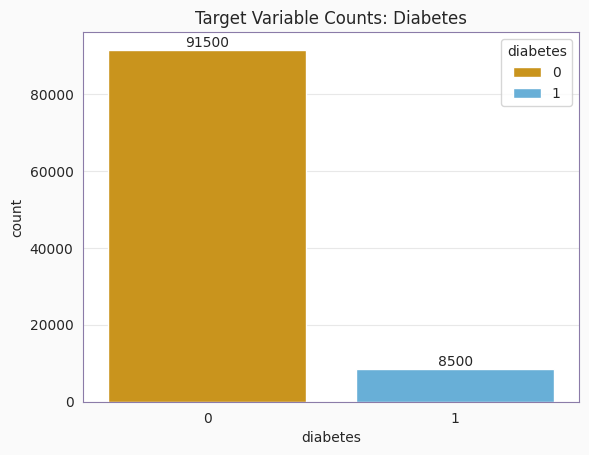

In [ ]:
#Imbalenced dataset
val_count_vis(df,'diabetes','Target Variable Counts: Diabetes')

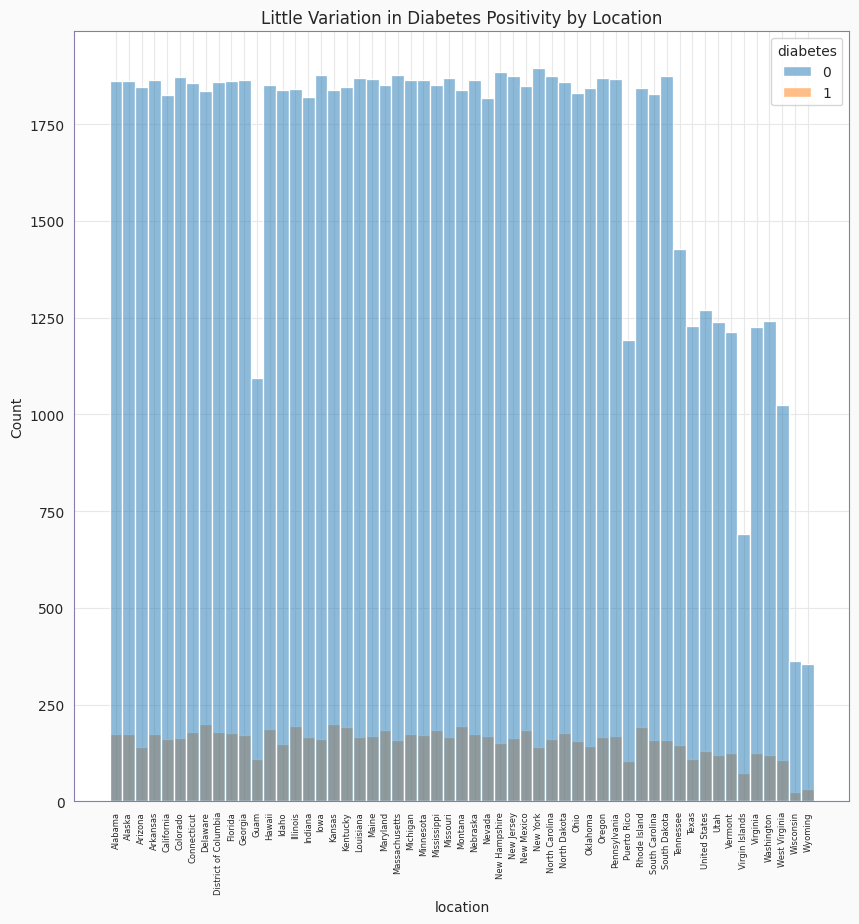

In [ ]:
plt.figure(figsize=(10,10))
sns.histplot(df, x='location', hue='diabetes', color=okabe_Ito_palette[0])
plt.xticks(rotation=90, fontsize=6)
plt.title('Little Variation in Diabetes Positivity by Location')
plt.show()

#### Correlation Matrix
##### Heatmap and Supportive Stats
Race only correlates with two `has_sentence_x` features. The value counts below show that `race:AfricanAmerican` is the only group for whom Sentence 6 has been applied, while the same is true for Sentence 7 and `race:Hispanic`.

These sentences are being used exclusively for two groups, and included for all members of the group, and excluded from all others. This seems unrealistic, and biased.



<Axes: >

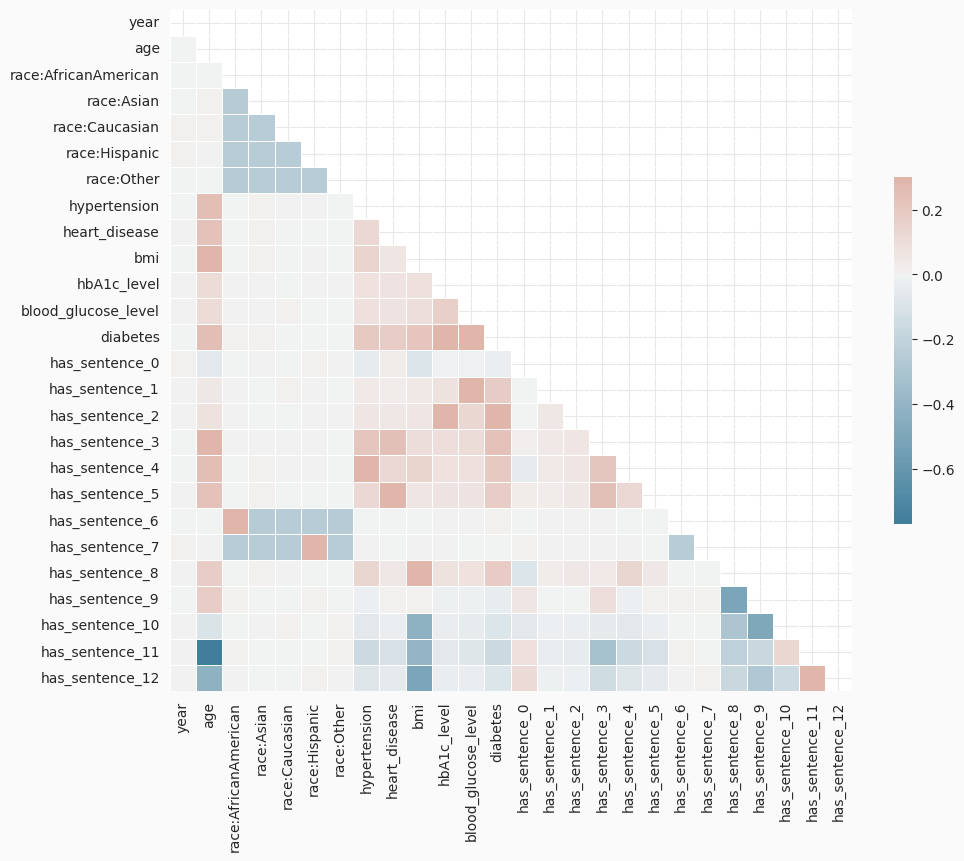

In [ ]:
#Heatmap code following pandas documentation: uses diverging palette rather than default.
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11,9))
cmap = sns.diverging_palette(230,20,as_cmap=True)# Better contrast than custum
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink" : .5})

In [ ]:
df_hyper_risk = df_with_clin_notes[df_with_clin_notes.has_sentence_6 == 1]#6: Higher predisposition to hypertension and diabetes.
df_metabolic = df_with_clin_notes[df_with_clin_notes.has_sentence_7 == 1]#7 = Consideration for metabolic syndrome and Type 2 diabetes.

df_hyper_risk[race_cols].sum()


,0
race:AfricanAmerican,20223
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0


In [ ]:
df_metabolic[race_cols].sum()

,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,19888
race:Other,0


In [ ]:
df_young = df_with_clin_notes[df_with_clin_notes.has_sentence_11 == 1]#'Young patient...'
df_young.age.describe()

,age
count,25885.000000
mean,12.605857
std,7.433971
min,0.080000
25%,6.000000
50%,13.000000
75%,19.000000
max,24.000000


In [ ]:
df_hb_di = df_with_clin_notes[df_with_clin_notes.has_sentence_2 == 1]# High HbA1c level, indicative of diabetes or poor glucose control.
print(f'Has Sentence 2 -> "High HbA1c...indicative of diabetes" :  mean hbA1c = {df_hb_di.hbA1c_level.mean():.2f}')
print(f'Population mean hbA1c level = {df.hbA1c_level.mean():.2f}')

Has Sentence 2 -> "High HbA1c...indicative of diabetes" :  mean hbA1c = 6.80
Population mean hbA1c level = 5.53


##### Co-correlation

Co-correlation between continuous features is fairly weak, with `bmi` and `age` showing the strongest connection, suggesting that the data moderately reflects the trend for weight gain with age (MedlinePlus, 2017). `hbA1c_level` and `blood_glucose_level` share a weak correlation, which is expected. `heart_disease` and `hypertension` are weakly correlated.

`year` is without correlation.

In [ ]:
corr_con = continuous_features.corr()
disc_con = non_race_discreate_features.corr()
both_sets = pd.concat([continuous_features, non_race_discreate_features], axis=1)
both_corr = both_sets.corr()

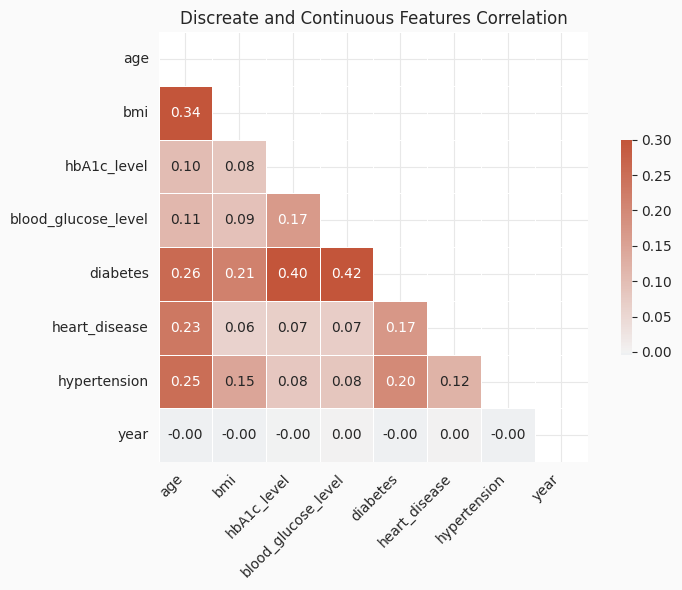

In [ ]:
dtype_corr(both_corr, 'Discreate and Continuous Features Correlation')

#### Pairplot
  

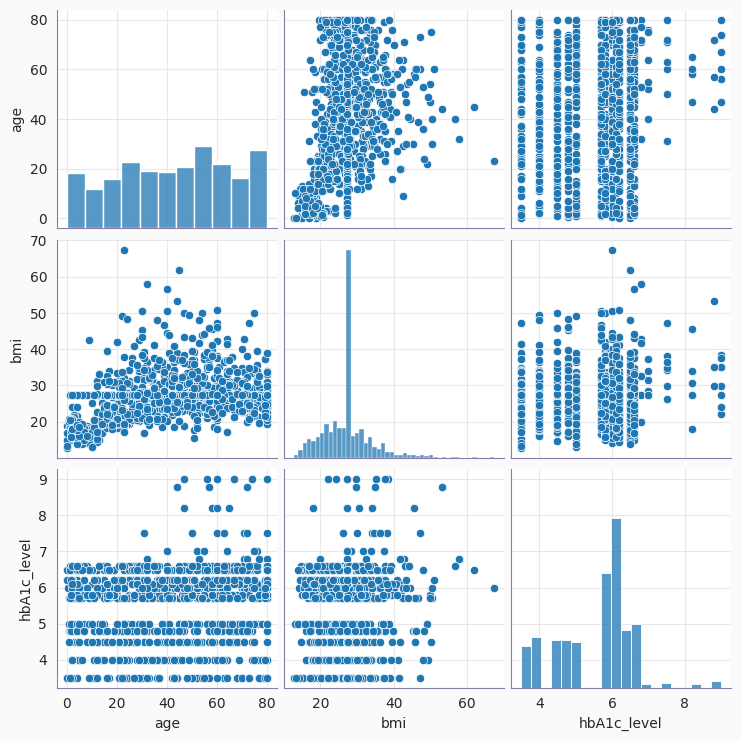

In [ ]:
sns.pairplot(continuous_features.sample(1000), palette=okabe_Ito_palette)
plt.show()

#### Scatter


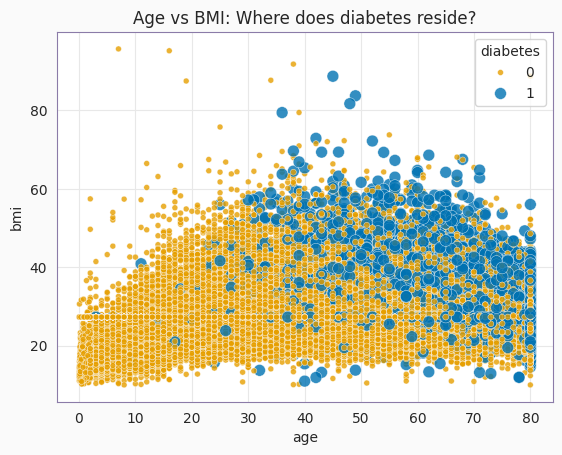

In [ ]:
#cmap_div = sns.diverging_palette(230,20)
sns.scatterplot(df, x='age', y='bmi', hue='diabetes',size='diabetes', size_order=[1,0],alpha=0.8, palette=[okabe_Ito_palette[0], okabe_Ito_palette[4]])
plt.title('Age vs BMI: Where does diabetes reside?')
plt.show()

#### Density
The density plot also shows positive samples clustered toward the upper right of the mass, and a smaller cluster of childhood diabetes: 66 positive samples were under 16\.

  

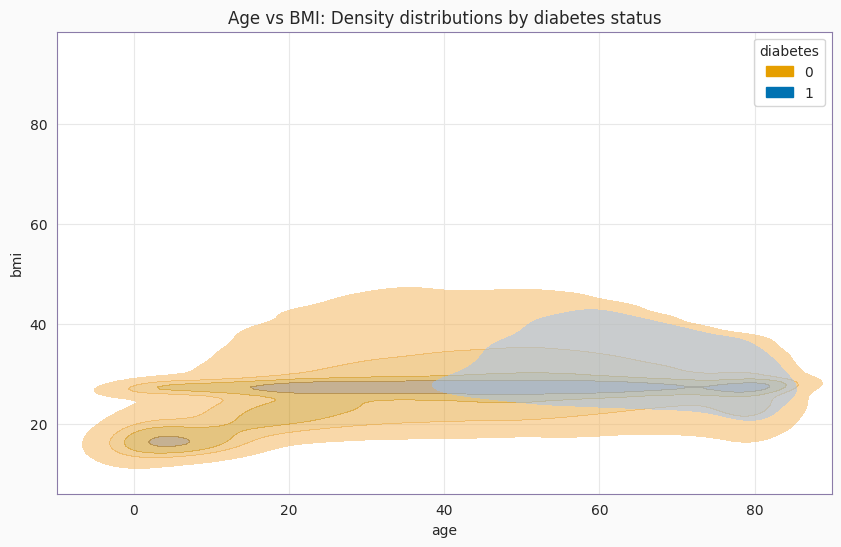

In [ ]:
#From chatGPT with some edits
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='age',
    y='bmi',
    hue='diabetes',
    fill=True,
    levels=5,
    palette=[okabe_Ito_palette[0], okabe_Ito_palette[4]],
    alpha=0.5
)
plt.title('Age vs BMI: Density distributions by diabetes status')
plt.show()


In [ ]:
df_youth = df[df.age < 16]
df_youth.diabetes.value_counts()

,count
diabetes,
0,15113
1,66


In [ ]:
print(df.hbA1c_level.unique())
print(len(df.hbA1c_level.unique()))

[5.  4.8 4.  6.5 5.7 6.  6.6 3.5 8.2 6.2 6.1 8.8 7.5 6.8 5.8 7.  4.5 9. ]
18


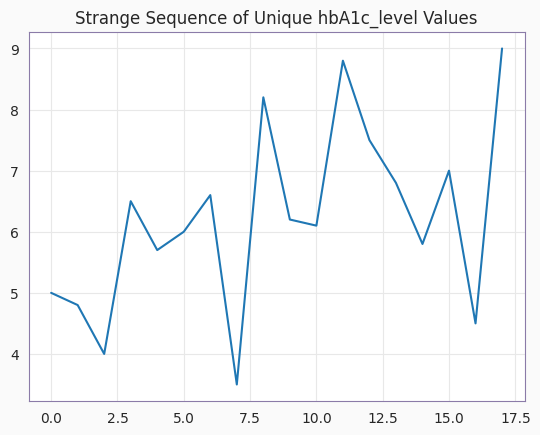

In [ ]:
hb_uniq = df.hbA1c_level.unique()
plt.plot(hb_uniq)
plt.title('Strange Sequence of Unique hbA1c_level Values')
plt.show()

The regularity of bumps in the tail of the `hbA1c_level` suggests it is not continuous, and is measured discretely; however, the list of unique values for this feature does not show a regular sequence (see line graph). That only 18 values are seen throughout may be evidence that this data has been partly or wholly synthetically generated. The same pattern is observable in `blood_glucose_level`.

18


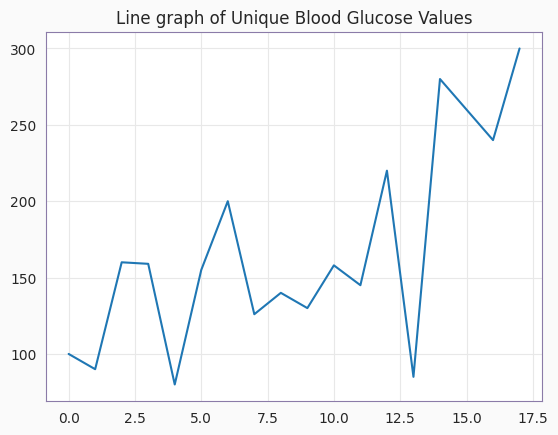

In [ ]:
print(len((df.blood_glucose_level.unique())))
blood_gluc_uniq = df.blood_glucose_level.unique()
plt.plot(blood_gluc_uniq)
plt.title('Line graph of Unique Blood Glucose Values')
plt.show()

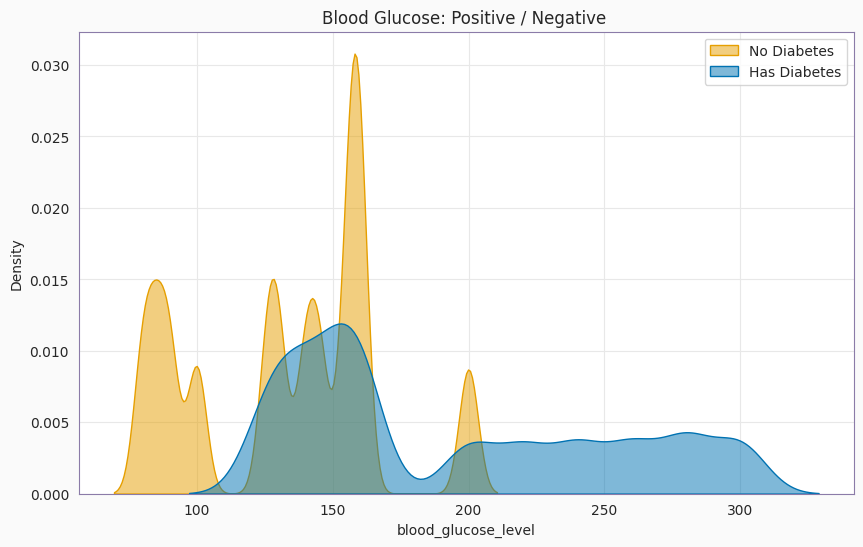

In [ ]:
distribution_by_diabetes(df, 'blood_glucose_level', title = "Blood Glucose: Positive / Negative " )

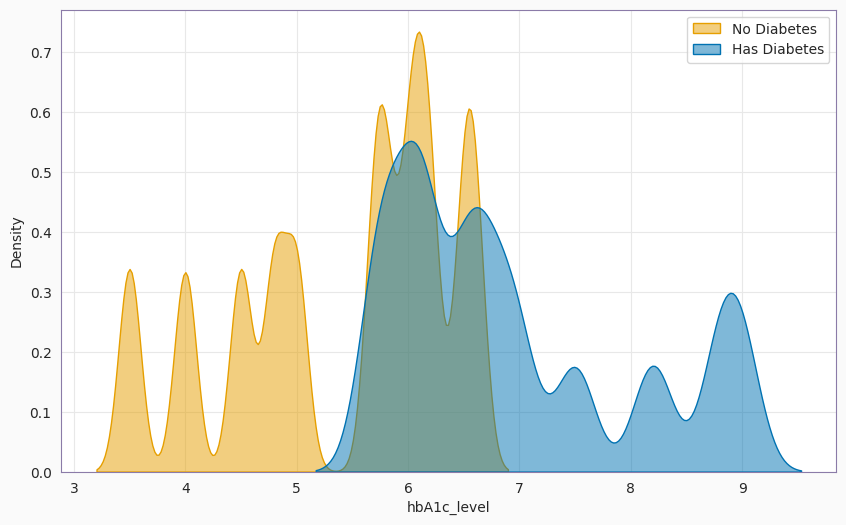

In [ ]:
distribution_by_diabetes(df, 'hbA1c_level')

#### Box and Violin



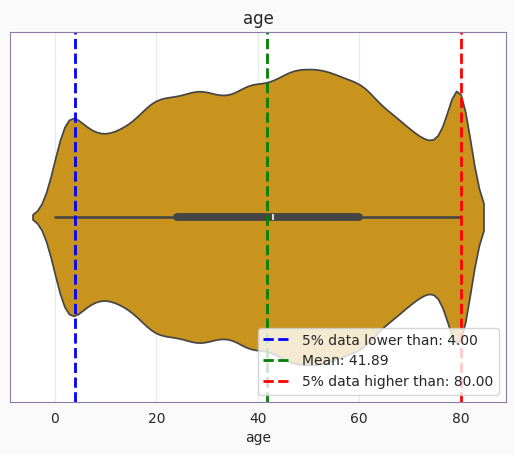

In [ ]:
mean_target(df,'age')

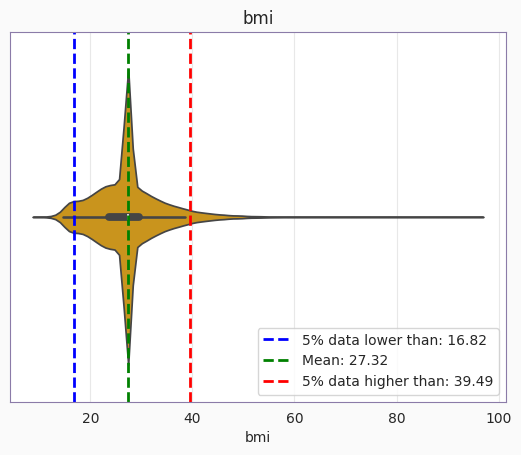

In [ ]:
mean_target(df,'bmi')

### Outliers

Compare the violin plots of `bmi` and `age`:. 90% of `bmi` data is tightly bound within \~35% of its entire range, while the upper 5% occupies \~60% of that range.

It might seem beneficial to remove higher BMI negative samples from the data, however they are not impossible: one man had a BMI as high as 84, with blood sugar 78 mg/dl (Yoshizawa et al., 2018), for example.

As such, it would seem to reduce the odds of this dataset reflecting reality in a meaningful way if these were to be removed.

`Gender` class 'Other' is, as discussed, a jaundiced subset within the wider data, being that it does not represent the reality of non-binary percentages amongst Americans, but to remove this subset altogether would once again seem to be reducing the margin of reality.

In [ ]:
print(f"Highest bmi : {df.bmi.max()}")
other_gen = df[df.gender.str.contains('Other')]
other_race = df[df['race:Other'] == 1 ]
print(f'Other gender positive diabetes = {other_gen.diabetes.sum()}')

print(np.sum(df.bmi > 70))
df.bmi.quantile([.05, .25, .5, .75, .975])

Highest bmi : 95.69
Other gender positive diabetes = 0
19


,bmi
0.050,16.82000
0.250,23.63000
0.500,27.32000
0.750,29.58000
0.975,43.53025


## Preprocessing

In [ ]:
df = df_raw.copy()#copying the raw data, so as to avoid any contamination from within the EDA

In [ ]:
df.info()#Check that original features are all still there and no new ones added.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [ ]:
df_replaced = df.replace('No Info','ever')#FILL MISSING VALUES

In [ ]:
df_replaced.smoking_history.value_counts()

,count
smoking_history,
ever,39820
never,35095
former,9352
current,9286
not current,6447


In [ ]:
#Encode Clinical Notes
df_sentences_encoded = clin_notes_encode(df_replaced)
df_sentences_encoded.drop(columns=['clinical_notes'], inplace=True)

In [ ]:
df_sentences_encoded.sample(2, random_state=SEED)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,has_sentence_0,has_sentence_1,has_sentence_2,has_sentence_3,has_sentence_4,has_sentence_5,has_sentence_6,has_sentence_7,has_sentence_8,has_sentence_9,has_sentence_10,has_sentence_11,has_sentence_12
75721,2019,Female,80.0,Oklahoma,1,0,0,0,0,0,1,current,17.01,4.8,200,0,1,1,0,1,0,1,1,0,0,0,0,0,1
80184,2019,Female,25.0,Pennsylvania,0,1,0,0,0,0,0,never,48.35,6.5,145,0,0,1,1,0,0,0,0,0,1,0,0,0,0


### Train, Test, and Validation Data Splits  


In [ ]:
#Split target and features
X = df_sentences_encoded.drop('diabetes', axis=1)
y = df_sentences_encoded['diabetes']

In [ ]:
#split into training/testing/validation sets, with a ratio of 60/20/20 because of data abundance
#USE STRATIFY TO MAINTAIN CLASS BALENCE!
#80% 'temp' 20% for testing
X_temp, X_test, y_temp, y_test = train_test_split( X, y, test_size=0.2, random_state=SEED, stratify=y)
#60% Training 20 validation
X_train_base, X_validation, y_train_base, y_validation = train_test_split(X_temp, y_temp, test_size=0.25,
                                                                          random_state=SEED, stratify=y_temp)

In [ ]:
X_train_base.info()#check Xtrain features are as expected

<class 'pandas.core.frame.DataFrame'>
Index: 60000 entries, 30908 to 56013
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  60000 non-null  int64  
 1   gender                60000 non-null  object 
 2   age                   60000 non-null  float64
 3   location              60000 non-null  object 
 4   race:AfricanAmerican  60000 non-null  int64  
 5   race:Asian            60000 non-null  int64  
 6   race:Caucasian        60000 non-null  int64  
 7   race:Hispanic         60000 non-null  int64  
 8   race:Other            60000 non-null  int64  
 9   hypertension          60000 non-null  int64  
 10  heart_disease         60000 non-null  int64  
 11  smoking_history       60000 non-null  object 
 12  bmi                   60000 non-null  float64
 13  hbA1c_level           60000 non-null  float64
 14  blood_glucose_level   60000 non-null  int64  
 15  has_sentence_0      

###Encoding and Scaling

In [ ]:
#Define feature groups by splitting
#Binary
has_sentence_cols = X.columns[X.columns.str.contains('has_sent')]
binary_features = ['hypertension', 'heart_disease'] + list(race_cols.values) + list(has_sentence_cols)

#Floating point/real
floating_point_features = ['age', 'bmi', 'hbA1c_level']

#integers
numeric_features = ['blood_glucose_level']

#categoric
categoric_features = ['gender', 'location', 'smoking_history', 'year']#includine year as most data is from one year, and has minimal correlation.

#### Pipelines Defined

In [ ]:
#Preprocessing Pipeline for base logistic regression without scaling. drop='first' to reduce dimentionality for Logistic Regression
preprocessing_base_no_scale_with_cat = ColumnTransformer(transformers=[
    ('binary', 'passthrough', binary_features),
    ('floats', 'passthrough', floating_point_features),
    ('numeric', 'passthrough', numeric_features),
    ('catagoric', OneHotEncoder(drop='first'), categoric_features)
])
#Preprocessing WITH scaling for linear models
preprocessing_scaled_lr_with_cat = ColumnTransformer(transformers=[
    ('binary', 'passthrough', binary_features),
    ('floats', StandardScaler(), floating_point_features),
    ('numeric', StandardScaler(), numeric_features),
    ('catagoric', OneHotEncoder(drop='first'), categoric_features)
])


## RQ 1 : Training Base Models
  #### Linear Models

Logistic Regression (LR) and Support Vector Machines (SVC) both form a linear decision boundary by adjusting coefficients.

LR mixes linear separability with probability. The relationship between inputs and the boundary is mapped by a logit function to a set of real numbers that correspond to a sigmoid function, the shape of which aids binary classification.    

SVMs define a decision boundary with hyperplanes on either side that represent the closest samples to the original boundary, creating a margin. SVC seeks to maximise the margin separating classes. (Raschka et al., 2022, pp.60, 77\)

#### Tree-Based Ensemble Models

Decision Tree-based models continuously split data, essentially by asking questions about feature classes and splitting via the answers into a familiar tree shape, with leaf nodes corresponding to outcomes.   

RF averages the output of multiple trees (ensemble) with high variance to create a robust model.  Xtreme Gradient Boosting (XGB) adds trees one at a time, measuring and minimising error as more trees are added (Raschka et al., 2022, pp.60, 77, 86, 95–96), (xgboost developers, 2022).

##### Timing

If these models were to be used in healthcare, they would likely require updating as new data becomes available, so speed is important; lives are affected. LR and XGB take seconds, while the SVC models take one to two+ minutes..

#### Conclusion

 XGB combines a good CV-score with speed, while both SVC models had issues.   

In [ ]:
base_lr_pipe_with_scaling = Pipeline([
    ('preprocessor', preprocessing_scaled_lr_with_cat),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])

base_lr_pipe_with_scaling.fit(X_train_base, y_train_base)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentence_8',
                                                   'has_sentence_9',
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', StandardScaler(),
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
base_svc = Pipeline([
    ('preprocessor', preprocessing_scaled_lr_with_cat),
    ('model', SVC(class_weight='balanced',random_state=SEED))
])
base_svc.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentence_8',
                                                   'has_sentence_9',
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', StandardScaler(),
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('model', SVC(class_weight='balanced', random_state=42))])

In [ ]:
base_svc_no_balence = Pipeline([
    ('preprocessor', preprocessing_scaled_lr_with_cat),
    ('model', SVC(random_state=SEED))
])
base_svc_no_balence.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentence_8',
                                                   'has_sentence_9',
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', StandardScaler(),
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('model', SVC(random_state=42))])

In [ ]:
base_rf_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('model', RandomForestClassifier(n_estimators=100, random_state=SEED))
])
base_rf_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentence_8',
                                                   'has_sentence_9',
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', 'passthrough',
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', 'passthrough',
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
base_xgb_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('model', XGBClassifier(eval_metric='logloss', random_state=SEED ))
])

base_xgb_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Model Metrics: Base Models

In [ ]:
#Keep a list of base mosels for later nd for interracting with functions.
base_models = {
    'Base LR Scaled' : base_lr_pipe_with_scaling,
    'Base Random Forest' : base_rf_pipe,
    'Base XGB Classifier' : base_xgb_pipe,
    'Base SVC' : base_svc,
    'Base SVC No-balenced' : base_svc_no_balence,
}

Base LR Scaled
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.87      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000

Recall : 0.6258823529411764


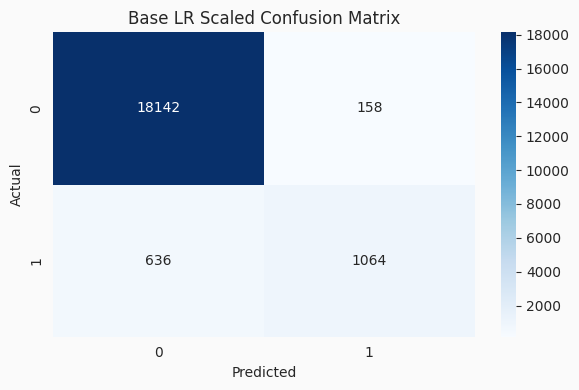

___________________________________________________________________________
Base Random Forest
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.99      0.68      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.678235294117647


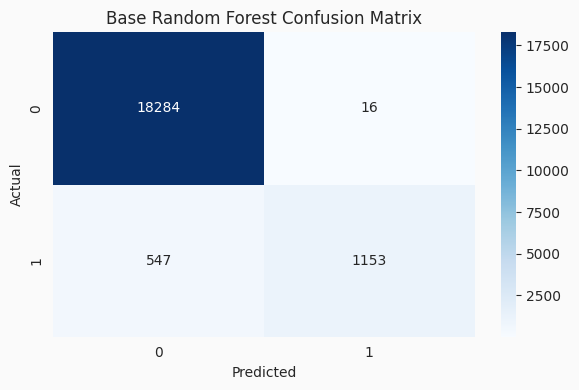

___________________________________________________________________________
Base XGB Classifier
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.70      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6982352941176471


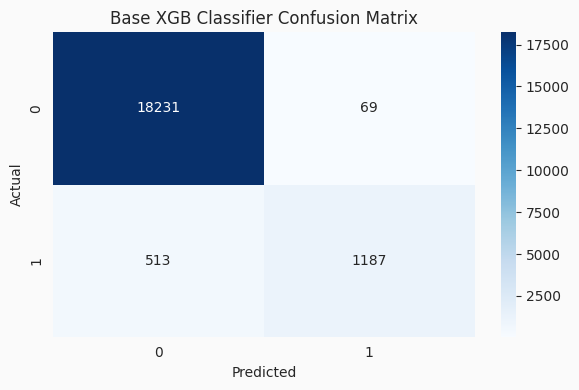

___________________________________________________________________________
Base SVC
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18300
           1       0.46      0.90      0.61      1700

    accuracy                           0.90     20000
   macro avg       0.72      0.90      0.78     20000
weighted avg       0.94      0.90      0.92     20000

Recall : 0.898235294117647


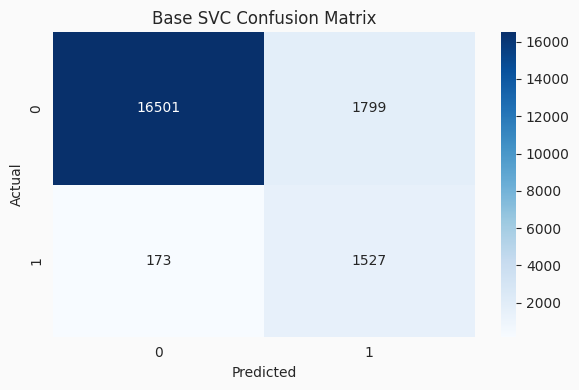

___________________________________________________________________________
Base SVC No-balenced
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.98      0.60      0.75      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.80      0.86     20000
weighted avg       0.97      0.97      0.96     20000

Recall : 0.6041176470588235


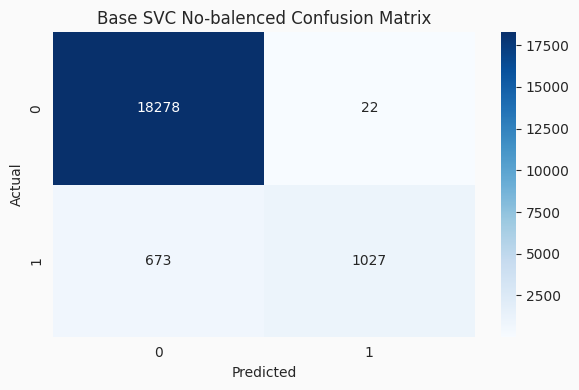

___________________________________________________________________________


In [ ]:
for model_name, model in base_models.items():
  print(model_name)
  print('_'*75)
  basic_scores(X_validation, y_validation, model, model_name)
  print('_'*75)

##### Cross-Validation

In [ ]:
def cross_val_collector(model_dict, X_train_ , y_train_, scoring: str = 'f1_macro', display: bool = True, timer: bool = False):
  '''
  Description: Performs cross validation on segments of data defined by the global CV_DEFINED
  `f1_macro` is now set as the default, as this helps preserve the importance of positive target samples
  in this imbalenced dataset.

  '''
  #define dict to return
  cv_collection = defaultdict(list)
  timings = defaultdict(list)
  #Begin cross validatione
  cv = CV_DEFINED

  for model_name, model in model_dict.items():#n_jobs -1 = use all available processors
    #Start timer if timing
    if timer:
      start = time.time()

    #Perform cv
    cv_score = cross_val_score(model,  X_train_, y_train_, cv=cv, scoring = scoring, n_jobs=-1 ) #Perform cv
    #cv_collection[model_name].append(cv_score)#Strore results

    #Stop and stor if timing
    if timer:
      timings[model_name] = time.time() - start

    cv_collection[model_name] = cv_score #Strore results

    if display:#Display if requested
      print(model_name)
      print(f"AVG CV f1_macro : {np.mean(cv_score)} ")

  if timer:
    return cv_collection, timings

  return cv_collection




In [ ]:
#Cross Validation
cv_base_collection, times = cross_val_collector(base_models, X_train_base, y_train_base, timer =True)

Base LR Scaled
AVG CV f1_macro : 0.8571132869121992 
Base Random Forest
AVG CV f1_macro : 0.892799449655054 
Base XGB Classifier
AVG CV f1_macro : 0.8918246393087053 
Base SVC
AVG CV f1_macro : 0.7761937058336842 
Base SVC No-balenced
AVG CV f1_macro : 0.8639483435143698 


In [ ]:
# @title
for name, scores in cv_base_collection.items():
  print(name)
  print(np.sum(scores) / CV_DEFINED)
  print('_'*50)


Base LR Scaled
0.8571132869121992
__________________________________________________
Base Random Forest
0.892799449655054
__________________________________________________
Base XGB Classifier
0.8918246393087053
__________________________________________________
Base SVC
0.7761937058336842
__________________________________________________
Base SVC No-balenced
0.8639483435143698
__________________________________________________


#### Training Time

In [ ]:
for model_name, model_time in times.items():
  print(f"{model_name} -> time :  {model_time}")

Base LR Scaled -> time :  1.9388649463653564
Base Random Forest -> time :  7.406052112579346
Base XGB Classifier -> time :  2.6898040771484375
Base SVC -> time :  133.7007954120636
Base SVC No-balenced -> time :  70.15322756767273


## RQ 2 : Feature Engineering
Feature importance is tracked by some sklearn models (except SVC), and can be extracted from pipelines, either directly as feature names and importance figures or in the case of LR, by extracting coefficients.   

#### Assumptions

Based on the EDA, certain assumptions were made:  

-  `race:x`, `year`, and `location` features were weak  
- Those directly associated with/referencing blood sugar would be strongest

#### Reality

- **Blood sugar features are highly important**.    
- `age` is always in the top 7   
- `bmi` isn’t as important as expected.   
- `Has_sentence_n` features are important for LR and RF, while less so in XGB  
- XGB uses the location-based features.   
- Both ensemble models rely heavily on a few strong features.

#### Feature Reduction

Recall was used as the reduction metric due to the desire for its increase, with highest recall as the cutoff. The importance of strong initial features can be seen in the log curves, as recall increases rapidly.

#### Results

-  XGB retained around 40% of its features  
- LR and RF dropped over 80%  
- Recall improved generally.  
-  SVC was degraded which is reflected in cross-validation.

##### Conclusion

Using recall as the metric for feature reduction improved recall overall (except for SVC), suggesting that feature reduction *can* improve model performance.

In [ ]:
def get_feature_importance_df(pipe, mod_type: str = 'ensemble'):
  ''' Description: Extracts Feature importances from the pipe lines and creates
      a dataframe for use with graphing
  '''
  #Basic importence Code from claude.ai, adapted to my needs, back and forth
  if mod_type == 'ensemble':

    #extract feature importances and feature names
    importance_base = pipe.named_steps['model'].feature_importances_
    feature_names = pipe['preprocessor'].get_feature_names_out()
    #Check feature selection as it changes the method
    if 'feature_selection' in pipe.named_steps:
      selected_mask = pipe['feature_selection'].get_support()
      feature_names = feature_names[selected_mask]

    #Create dataframe
    df_importance_base = pd.DataFrame({
        'Feature':feature_names,
        'Importance':importance_base
    }).sort_values('Importance',ascending=False)

    return df_importance_base

  elif mod_type == 'linear':
    #extract feature importances and names
    coefficients_lr = pipe.named_steps['model'].coef_[0]
    feature_names_lr = pipe.named_steps['preprocessor'].get_feature_names_out()

     #Check feature selection in the pipeline
    if 'feature_selection' in pipe.named_steps:
        selector = pipe.named_steps['feature_selection']
        selected_mask = selector.get_support()
        feature_names_lr = feature_names_lr[selected_mask]

    #create dataframe
    df_importance_base = pd.DataFrame({
        'Feature': feature_names_lr,
        'coefficient': coefficients_lr,
        'abs_coefficient': np.abs(coefficients_lr)
    }).sort_values('abs_coefficient', ascending=False)

    return df_importance_base



In [ ]:
#Random Forest importence
df_importance_base_rf = get_feature_importance_df(base_rf_pipe)

#XGB feature importence
df_importance_base_xgb = get_feature_importance_df(base_xgb_pipe)

#Logistic Regression importance
df_scaled_lr = get_feature_importance_df(base_lr_pipe_with_scaling, mod_type = 'linear')

In [ ]:
def feature_importance_graph(df_imp, mod_name, mod_type: str = 'ensemble'):
  ''' Descirption: Shows Top 15 features by importance '''
  #adapted claude.ai code into a function
  if mod_type == 'ensemble':
    df_imp.head(15).plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))
  elif mod_type == 'linear':
    df_imp.head(15).plot(x='Feature', y='abs_coefficient', kind='barh', figsize=(10, 6))

  plt.xlabel('Importance')
  plt.title(f'Top 15 Feature Importances in {mod_name}')
  plt.show()

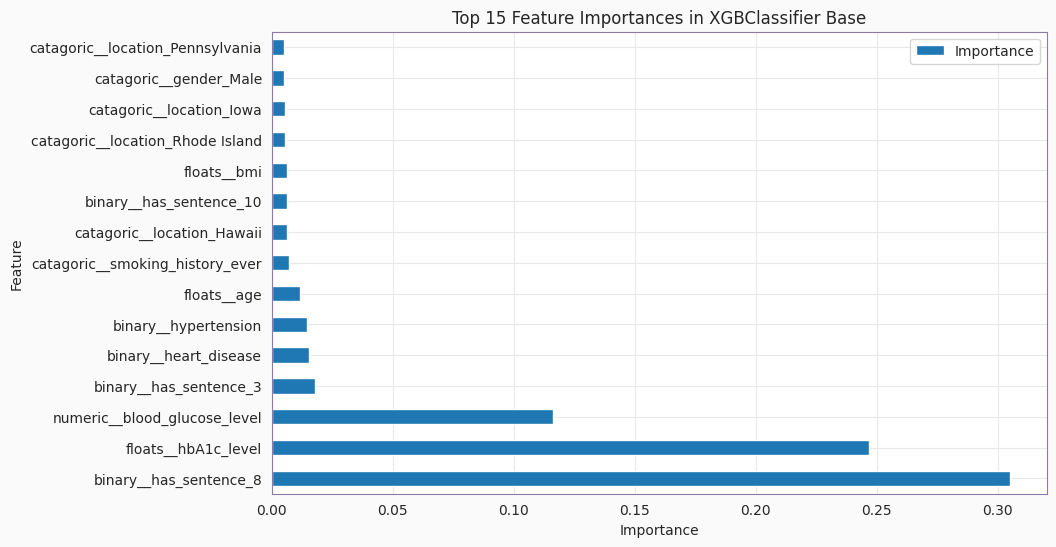

In [ ]:
feature_importance_graph(df_importance_base_xgb, 'XGBClassifier Base')

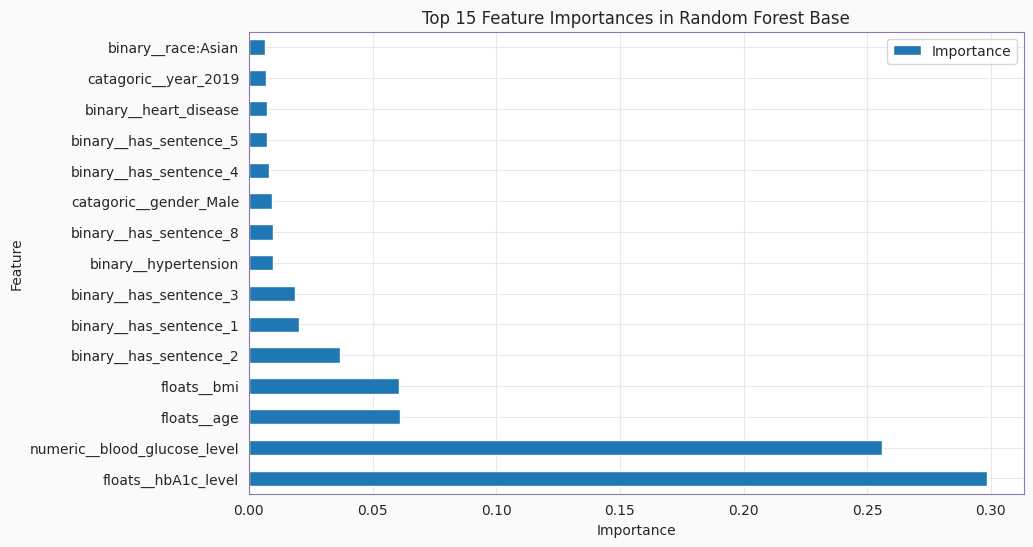

In [ ]:

feature_importance_graph(df_importance_base_rf, 'Random Forest Base' )

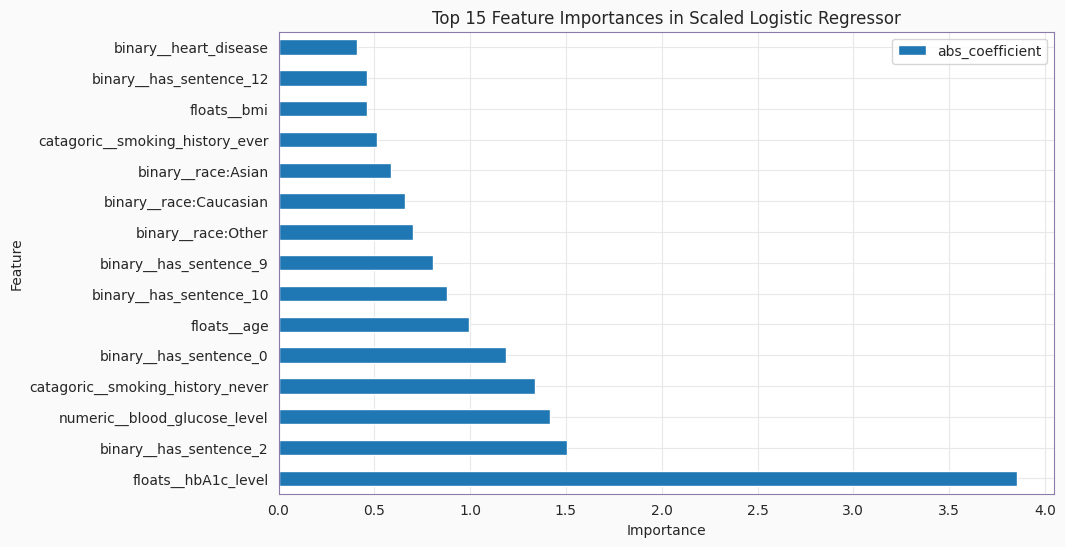

In [ ]:
feature_importance_graph(df_scaled_lr, 'Scaled Logistic Regressor', mod_type='linear')

#### Tuning k Features
Each `k` is examiined for each model to discover the optimal number of features in terms of recall. As before. the 'recall/precision balence'comes into question when we consider the results of the `SVC` model, as does training time.

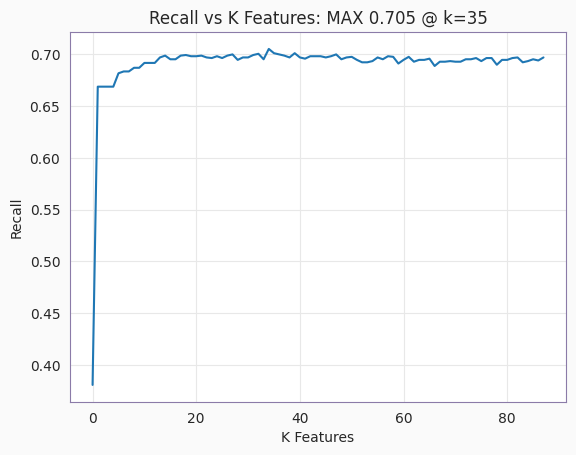

In [ ]:
best_k_xgb,_ = plot_recall_by_k_features(
    base_xgb_pipe,
    X_train_base,
    y_train_base,
    X_validation,
    y_validation)


In [ ]:
selected_xgb_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('feature_selection', SelectKBest(score_func=f_classif, k=best_k_xgb)),# From machine learning mastery
    ('model', XGBClassifier(eval_metric='logloss', random_state=SEED ))
])

selected_xgb_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
df_selected_xgb = get_feature_importance_df(selected_xgb_pipe)

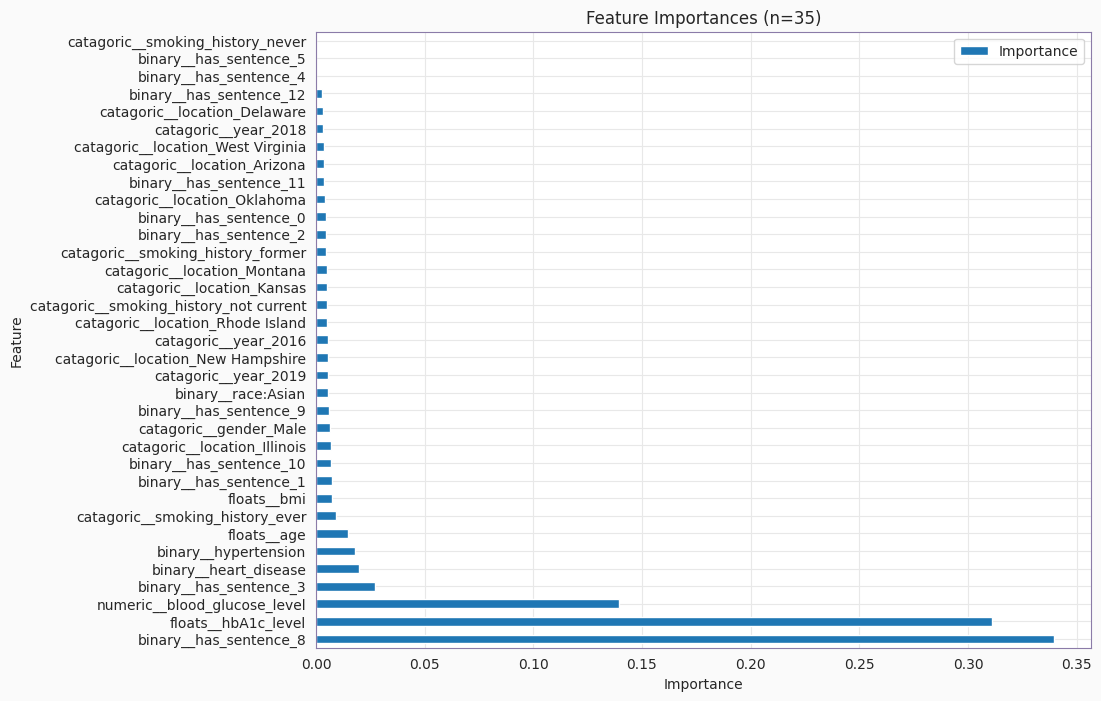

In [ ]:
#*quick claude generation
df_selected_xgb.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 8))
plt.xlabel('Importance')
plt.title(f'Feature Importances (n={len(df_selected_xgb)})')
plt.show()

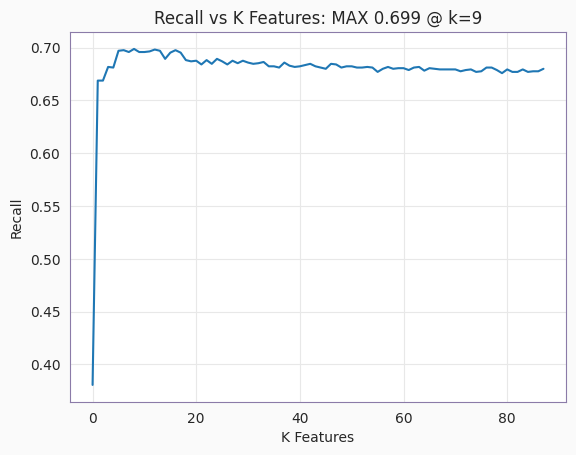

In [ ]:
best_k_rf,_ = plot_recall_by_k_features(
    base_rf_pipe,
    X_train_base,
    y_train_base,
    X_validation,
    y_validation)

In [ ]:
selected_rf_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('feature_selection', SelectKBest(score_func=f_classif, k=best_k_rf)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

selected_rf_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                                                   'has_sentence_9',
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', 'passthrough',
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', 'passthrough',
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('feature_selection', SelectKBest(k=9)),
                ('model', RandomForestClassifier(random_state=42))])

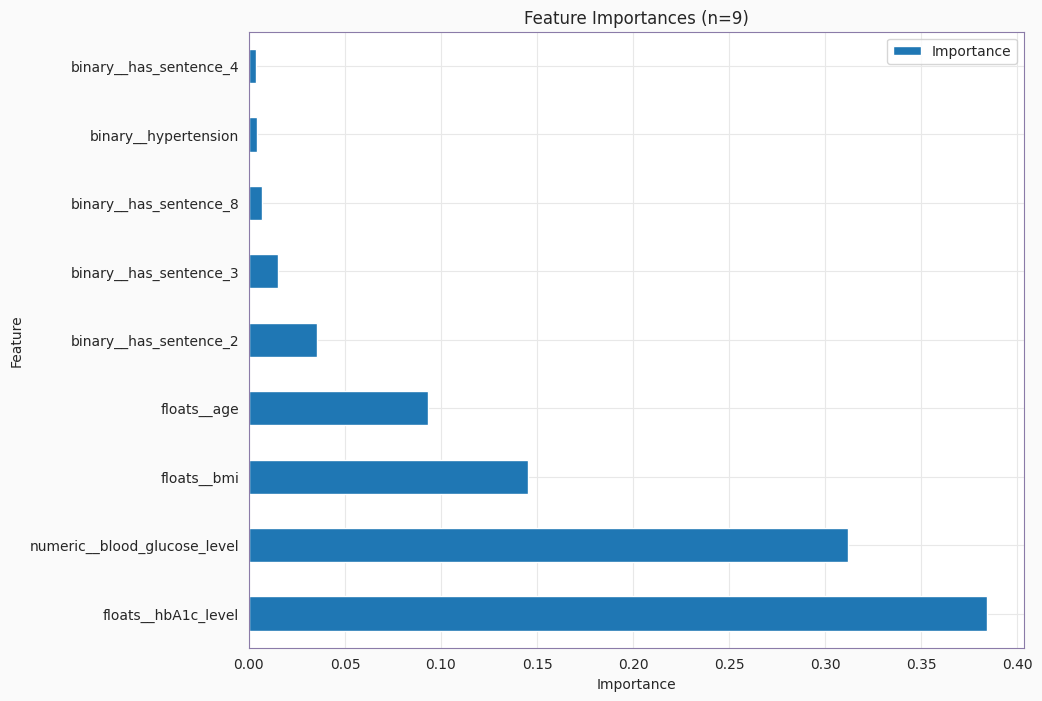

In [ ]:
df_selected_rf = get_feature_importance_df(selected_rf_pipe)
df_selected_rf.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 8))
plt.xlabel('Importance')
plt.title(f'Feature Importances (n={len(df_selected_rf)})')
plt.show()

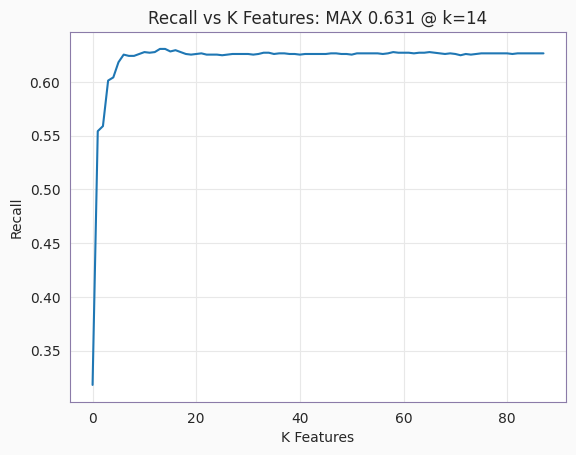

In [ ]:
best_k_lr,_ = plot_recall_by_k_features(
    base_lr_pipe_with_scaling,
    X_train_base,
    y_train_base,
    X_validation,
    y_validation)

In [ ]:
selected_lr_pipe = Pipeline([
    ('preprocessor', preprocessing_scaled_lr_with_cat),
    ('feature_selection', SelectKBest(score_func=f_classif, k=best_k_lr)),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])
selected_lr_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', StandardScaler(),
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('feature_selection', SelectKBest(k=14)),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

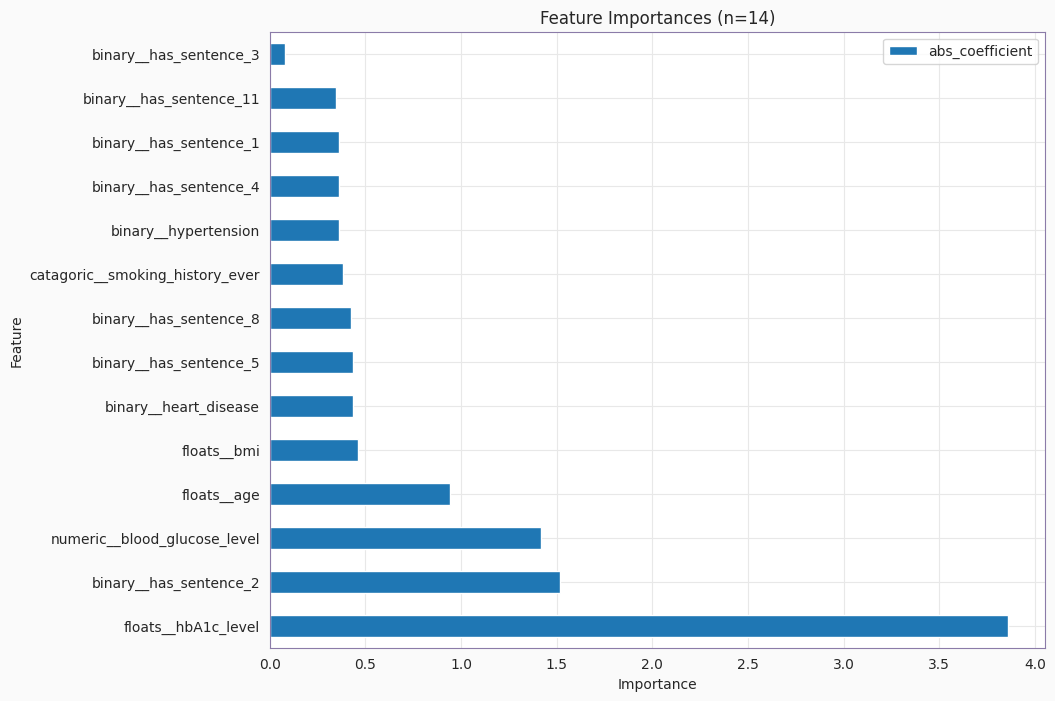

In [ ]:
df_selected_lr = get_feature_importance_df(selected_lr_pipe,mod_type = 'linear')
df_selected_lr.plot(x='Feature', y='abs_coefficient', kind='barh', figsize=(10, 8))
plt.xlabel('Importance')
plt.title(f'Feature Importances (n={len(df_selected_lr)})')
plt.show()

In [ ]:
'''best_k_svc,_ = plot_recall_by_k_features(
    base_svc ,
    X_train_base,
    y_train_base,
    X_validation,
    y_validation)
''' #SKIPPING AS TAKES UPWARDS OF 3 HOURS ON NORMAL RUNTIME

'best_k_svc,_ = plot_recall_by_k_features(\n    base_svc ,\n    X_train_base,\n    y_train_base,\n    X_validation,\n    y_validation)\n'

In [ ]:
best_svc_k = 4#Takes a long time, so temporary hardcoding necessary
selected_svc_pipe = Pipeline([
    ('preprocessor', preprocessing_scaled_lr_with_cat),
    ('feature_selection', SelectKBest(score_func=f_classif, k=best_svc_k)),
    ('model', SVC(class_weight='balanced',random_state=SEED))
])
selected_svc_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', StandardScaler(),
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('feature_selection', SelectKBest(k=4)),
                ('model', SVC(class_weight='balanced', random_state=42))])

#### Model Metrics: Feature Engineered

In [ ]:
selected_models = {
    'Feature Selected Rf': selected_rf_pipe,
    'Feature Selected XGB' : selected_xgb_pipe,
    'Feature Selected LR' : selected_lr_pipe,
    'Feature Selected SVC' : selected_svc_pipe
}

Feature Selected Rf
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.90      0.70      0.79      1700

    accuracy                           0.97     20000
   macro avg       0.94      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6988235294117647


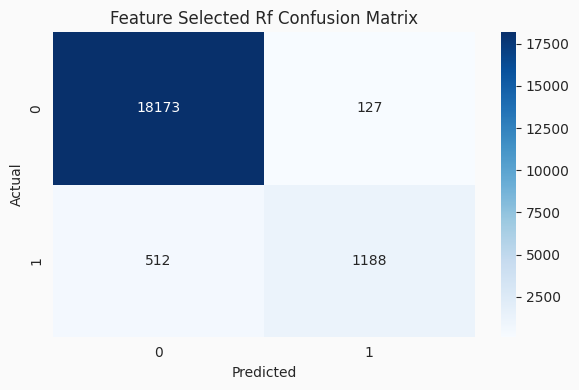

___________________________________________________________________________
Feature Selected XGB
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.71      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.85      0.90     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.7052941176470588


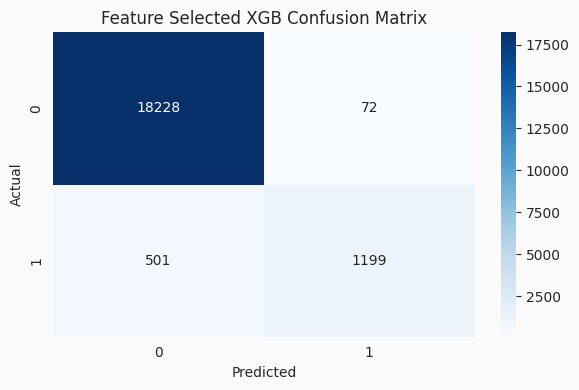

___________________________________________________________________________
Feature Selected LR
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.88      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Recall : 0.6305882352941177


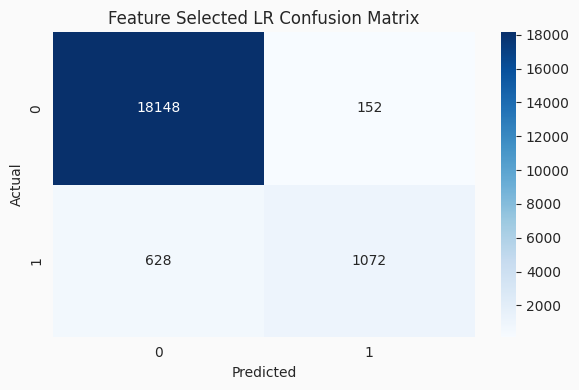

___________________________________________________________________________
Feature Selected SVC
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.99      0.85      0.92     18300
           1       0.37      0.94      0.53      1700

    accuracy                           0.86     20000
   macro avg       0.68      0.90      0.73     20000
weighted avg       0.94      0.86      0.88     20000

Recall : 0.9405882352941176


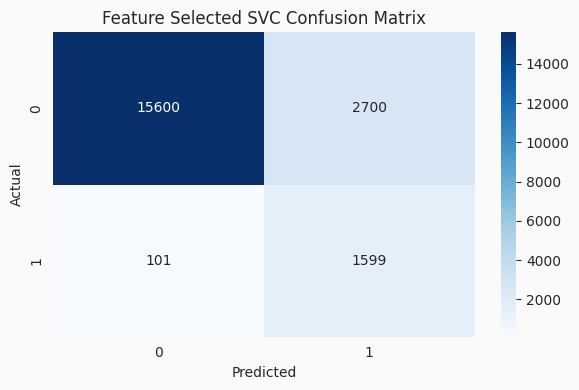

___________________________________________________________________________


In [ ]:
for model_name, model in selected_models.items():
  print(model_name)
  print('_'*75)
  basic_scores(X_validation, y_validation, model, model_name)
  print('_'*75)


##### Cross-Validation

In [ ]:
cv_selected_collection, selected_times = cross_val_collector(selected_models, X_train_base, y_train_base, timer=True)

Feature Selected Rf
AVG CV f1_macro : 0.8834961697661343 
Feature Selected XGB
AVG CV f1_macro : 0.891658855997006 
Feature Selected LR
AVG CV f1_macro : 0.8574089997090887 
Feature Selected SVC
AVG CV f1_macro : 0.7237417588695567 


In [ ]:
# @title
for name, scores in cv_selected_collection.items():
  print(name)
  print(np.mean(scores))
  print('_'*50)

Feature Selected Rf
0.8834961697661343
__________________________________________________
Feature Selected XGB
0.891658855997006
__________________________________________________
Feature Selected LR
0.8574089997090887
__________________________________________________
Feature Selected SVC
0.7237417588695567
__________________________________________________


## RQ 3 : Balenced Data: SMOTE
  
SMOTE uses synthetic minority over-sampling to rebalance datasets. ‘Sampling strategy’: this parameter controls the ratio of majority/minority class data (Scikit-learn Developers, 2025c).

As SVC offers `class_weight` balancing, the base version of SVC without self-balancing was used, for uninfluenced observation.

##### Results.      

- **Balancing data had little or a negative impact on F1**   
- Comparing CV scores with base models shows a heavily negative impact on LR   
  - performance reduction of \~0.1.   
- SVC unbalanced degraded.

#### Conclusion

Possibly the imbalance isn’t enough to warrant minority over-sampling, or the data reflects some reality about balancing when there is a natural imbalance.       

#### Metrics and Pipeline

##### Sampling Strategy Tuning Attempt

k = 0.5
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6911764705882353


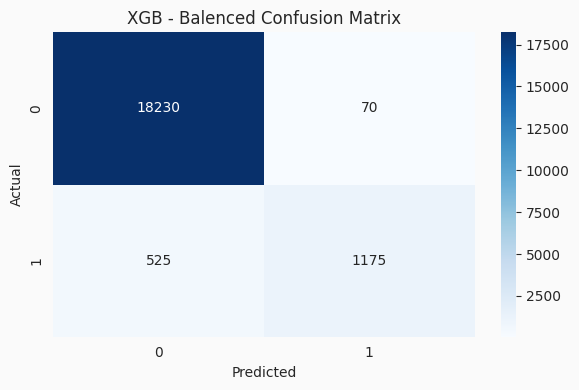

k = 0.6
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.691764705882353


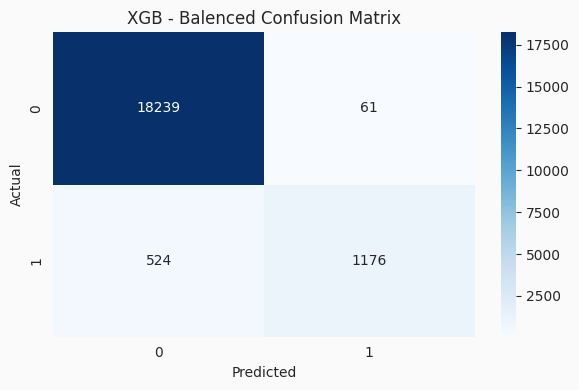

k = 0.7
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6894117647058824


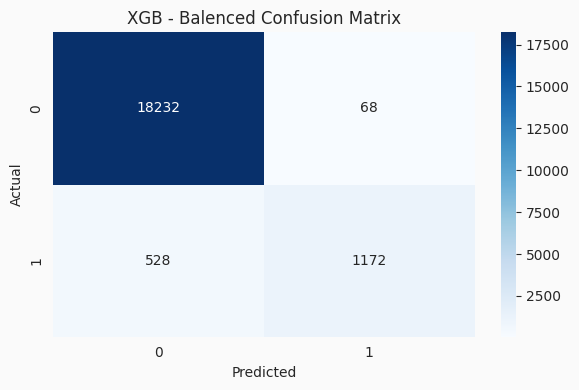

k = 0.8
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6941176470588235


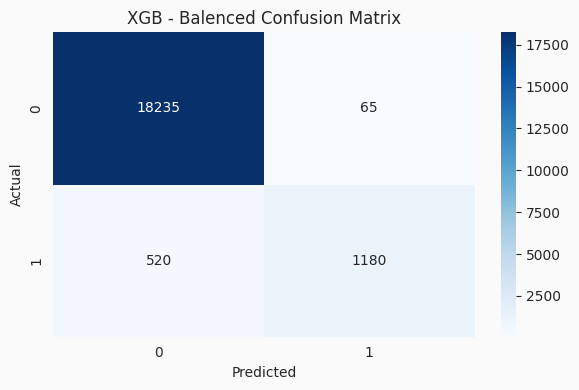

k = 0.9
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6935294117647058


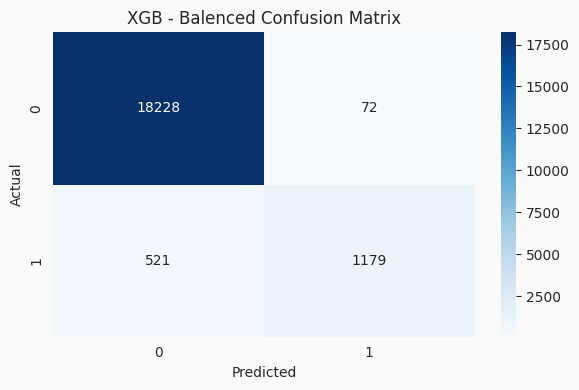

k = 1.0
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.691764705882353


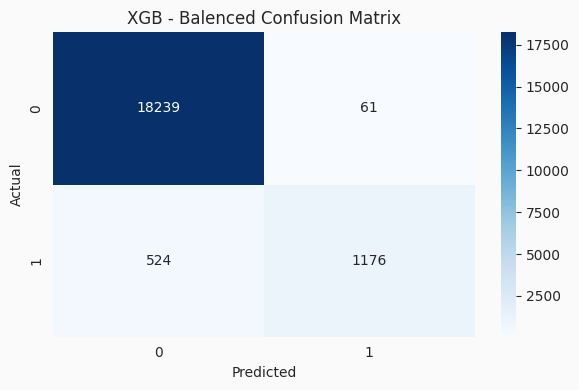

In [ ]:
for i in range(5,11): # resampling has little effect on recall, and sampling strategy has even less of an impact
  #Switch to imbpipeline for imputing, as normal sklearn pipeline doesn't consider y
  base_balenced_xgb_pipe = ImbPipeline([
      ('preprocessor', preprocessing_base_no_scale_with_cat),
      ('feature_selection', 'passthrough'),
      ('smote', SMOTE(random_state=SEED, sampling_strategy= i / 10 )),
      ('model', XGBClassifier(random_state=SEED, eval_metric='logloss'))
  ])
  print(f'k = {i / 10}')
  base_balenced_xgb_pipe.fit(X_train_base, y_train_base)
  basic_scores(X_validation, y_validation,base_balenced_xgb_pipe, 'XGB - Balenced')

k = 0.5
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     18300
           1       0.53      0.82      0.64      1700

    accuracy                           0.92     20000
   macro avg       0.76      0.88      0.80     20000
weighted avg       0.94      0.92      0.93     20000

Recall : 0.8223529411764706


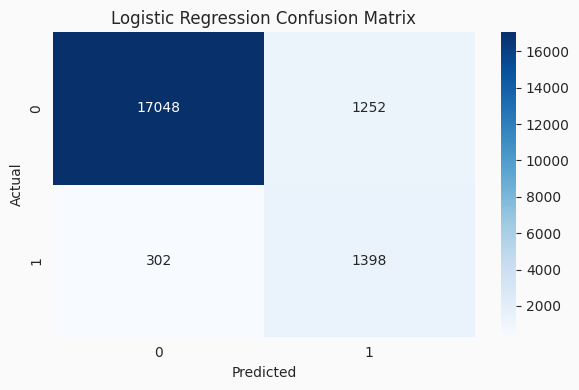

k = 0.6
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     18300
           1       0.49      0.84      0.62      1700

    accuracy                           0.91     20000
   macro avg       0.74      0.88      0.79     20000
weighted avg       0.94      0.91      0.92     20000

Recall : 0.8388235294117647


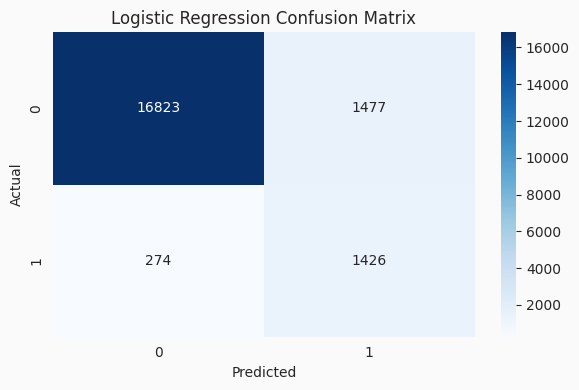

k = 0.7
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18300
           1       0.47      0.86      0.61      1700

    accuracy                           0.91     20000
   macro avg       0.73      0.88      0.78     20000
weighted avg       0.94      0.91      0.92     20000

Recall : 0.8576470588235294


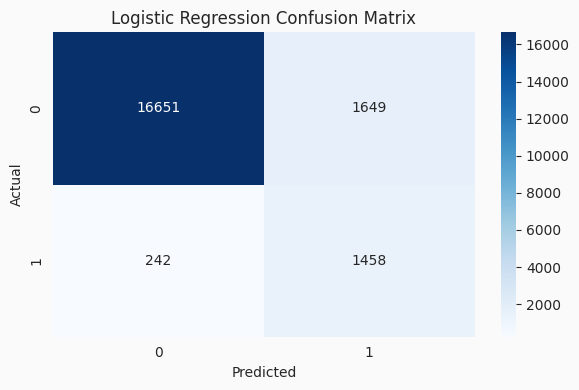

k = 0.8
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18300
           1       0.45      0.87      0.59      1700

    accuracy                           0.90     20000
   macro avg       0.72      0.89      0.77     20000
weighted avg       0.94      0.90      0.91     20000

Recall : 0.8729411764705882


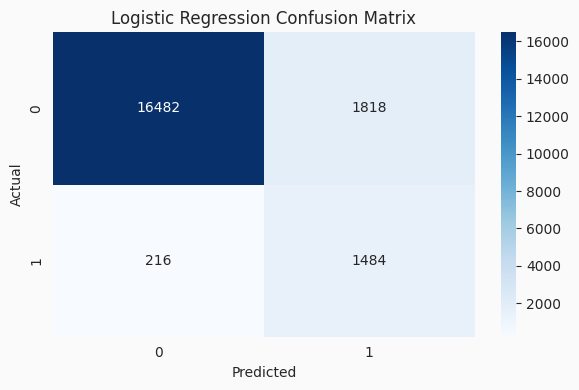

k = 0.9
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18300
           1       0.43      0.89      0.58      1700

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.76     20000
weighted avg       0.94      0.89      0.91     20000

Recall : 0.8858823529411765


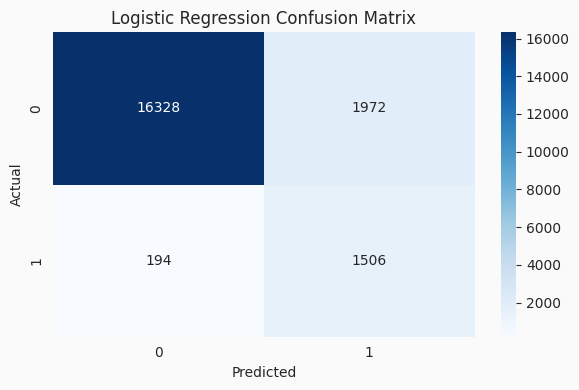

k = 1.0
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     18300
           1       0.42      0.89      0.57      1700

    accuracy                           0.89     20000
   macro avg       0.70      0.89      0.75     20000
weighted avg       0.94      0.89      0.90     20000

Recall : 0.8947058823529411


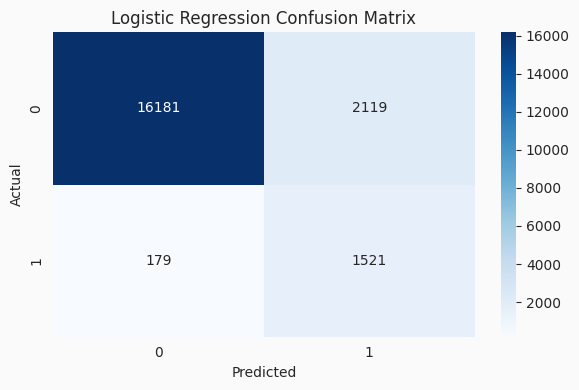

In [ ]:
for i in range(5,11):
  base_balenced_lr_pipe = ImbPipeline([
      ('preprocessor', preprocessing_scaled_lr_with_cat),
      ('feature_selection', 'passthrough'),
      ('smote', SMOTE(random_state=SEED, sampling_strategy= i / 10)),
      ('model', LogisticRegression(max_iter=1000, random_state=SEED))
  ])
  print(f'k = {i / 10}')
  base_balenced_lr_pipe.fit(X_train_base, y_train_base)
  basic_scores(X_validation, y_validation, base_balenced_lr_pipe, 'Logistic Regression')

In [ ]:
base_balenced_rf_pipe = ImbPipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('feature_selection', 'passthrough'),
    ('smote', SMOTE(random_state=SEED)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=SEED))
])
base_balenced_rf_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', 'passthrough',
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', 'passthrough',
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('feature_selection', 'passthrough'),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.96      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6864705882352942


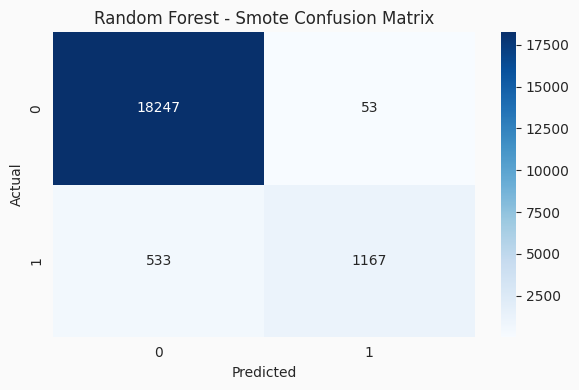

In [ ]:
basic_scores(X_validation, y_validation, base_balenced_rf_pipe, 'Random Forest - Smote')

In [ ]:
base_balenced_svc_pipe = ImbPipeline([
    ('preprocessor', preprocessing_scaled_lr_with_cat),
    ('feature_selection', 'passthrough'),
    ('smote', SMOTE(random_state=SEED)),
    ('model', SVC(random_state=SEED))
])
#class_weight='balanced',random_state=SEED
base_balenced_svc_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'race:AfricanAmerican',
                                                   'race:Asian',
                                                   'race:Caucasian',
                                                   'race:Hispanic',
                                                   'race:Other',
                                                   'has_sentence_0',
                                                   'has_sentence_1',
                                                   'has_sentence_2',
                                                   'has_sentence_3',
                                                   'has_sentence_4',
                                                   'has_sentence_5',
                                                   'has_sentence_6',
                                                   'has_sentence_7',
                                                   'has_sentenc...
                                                   'has_sentence_10',
                                                   'has_sentence_11',
                                                   'has_sentence_12']),
                                                 ('floats', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'hbA1c_level']),
                                                 ('numeric', StandardScaler(),
                                                  ['blood_glucose_level']),
                                                 ('catagoric',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'location',
                                                   'smoking_history',
                                                   'year'])])),
                ('feature_selection', 'passthrough'),
                ('smote', SMOTE(random_state=42)),
                ('model', SVC(random_state=42))])

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     18300
           1       0.58      0.80      0.67      1700

    accuracy                           0.93     20000
   macro avg       0.78      0.87      0.82     20000
weighted avg       0.95      0.93      0.94     20000

Recall : 0.798235294117647


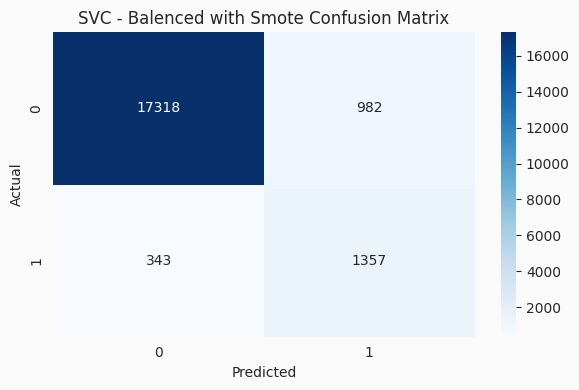

In [ ]:
basic_scores(X_validation,y_validation, base_balenced_svc_pipe, 'SVC - Balenced with Smote')

##### Cross-Validation

In [ ]:
balenced_models = {
    'Balenced Random Forest' : base_balenced_rf_pipe,
    'Balenced XGB' : base_balenced_xgb_pipe,
    'Balenced Logistic Regression' : base_balenced_lr_pipe,
    'Balenced SVC' : base_balenced_svc_pipe
}

In [ ]:
cv_balenced_collection = cross_val_collector(balenced_models, X_train_base, y_train_base)

Balenced Random Forest
AVG CV f1_macro : 0.8912248189279561 
Balenced XGB
AVG CV f1_macro : 0.8930328956756775 
Balenced Logistic Regression
AVG CV f1_macro : 0.7523836360857634 
Balenced SVC
AVG CV f1_macro : 0.8159323792185178 


## RQ 4: Hyperparameter Tuning
The initial parameters for tuning were chosen as they are well established (Brownlee, 2019), so might provide a solid base for further exploration.

##### Methodology:

1. Search widely and loosely with fixed parameters.  
2. Fine-tune around ‘best’ initial parameters.  

##### Removing SVC and Base Models

As SVC models are performing poorly and retraining them costly, they will not be furthered.

Cross-validation and p-value significance tests on base/tuned Linear Regression Models fail to show significant difference. Therefore, only feature-selected models will be fine-tuned

#### Fine Tuning   
The ranges for fine-tuning with \`RandomizedSearchCV\` were derived by examining the \`.best\_parms\_\` returned from `GridSearchCV`.

  

##### Results

- **The effect of fine-tuning is negligible.**   
- Little difference between fine-tuned CV and base CV

#### Conclusion

Better initial parameters would have helped or progression has plateaued, naturally.    

##### Base GridCV Tuning

In [ ]:
'''
Specify parameters for grid search.
Most of these parameters where sourced from machinelearningmastery.com.
This is not an ideal way to find intitial parameters, but the idea is to
further explore from base consensus using random search for fine tuning

'''
search_parameter_collection = {
    'Logistic Regression' : {
        'model__penalty' : ['l1','l2'],
        'model__C'       : [100, 10, 1.0, 0.1, 0.01],
        'model__solver'  : ['saga', 'liblinear'],
                             },
    'Random Forest' : {
        'model__max_features' : [5,10,15,20,'sqrt', 'log2', None],#Have to add model__ to get grid cv to look at models, not steps
        'model__n_estimators' : [5, 10, 50, 100, 1000]
    },
    'XGB' : {
        'model__learning_rate' : [0.001, 0.01, 0.1],
        'model__n_estimators' : [10, 100, 1000],
        'model__subsample' : [0.5, 0.7, 1.0],
        'model__max_depth' : [3, 7, 9]

    },
    'SVC' : {
        'model__kernel' : ['poly', 'rbf', 'sigmoid'],
        'model__C' : [50, 10, 1.0, 0.1, 0.01]
    }
}


In [ ]:

cv = CV_DEFINED
#Random forests
grid_search_rf_base = GridSearchCV(base_rf_pipe,search_parameter_collection['Random Forest'], n_jobs= -1, scoring = SCORE_STRING, cv=cv)
grid_search_rf_selected = GridSearchCV(selected_rf_pipe, search_parameter_collection['Random Forest'], n_jobs= -1, scoring = SCORE_STRING, cv=cv)
#fIT
grid_search_rf_base.fit(X_train_base, y_train_base)
grid_search_rf_selected.fit(X_train_base, y_train_base)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('binary',
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease',
                                                                          'race:AfricanAmerican',
                                                                          'race:Asian',
                                                                          'race:Caucasian',
                                                                          'race:Hispanic',
                                                                          'race:Other',
                                                                          'has_sentence_0',
                                                                          'has_sentence_1',
                                                                          'has_sentence_2',
                                                                          'has_sentence_3',
                                                                          'has_sentence_4',
                                                                          'has_sentence_5',
                                                                          'has_sentence_6',
                                                                          '...
                                                                         'passthrough',
                                                                         ['blood_glucose_level']),
                                                                        ('catagoric',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender',
                                                                          'location',
                                                                          'smoking_history',
                                                                          'year'])])),
                                       ('feature_selection', SelectKBest(k=9)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_features': [5, 10, 15, 20, 'sqrt', 'log2',
                                                 None],
                         'model__n_estimators': [5, 10, 50, 100, 1000]},
             scoring='f1_macro')

In [ ]:
#Display parameters, to inform further fine tuning with randomCV
print(grid_search_rf_base.best_params_)
print(grid_search_rf_selected.best_params_)

{'model__max_features': 15, 'model__n_estimators': 100}
{'model__max_features': 'sqrt', 'model__n_estimators': 100}


In [ ]:
#XGB
grid_search_xgb_base = GridSearchCV(base_xgb_pipe ,search_parameter_collection['XGB'], n_jobs= -1, scoring = SCORE_STRING, cv=cv)
grid_search_xgb_selected = GridSearchCV(selected_xgb_pipe ,search_parameter_collection['XGB'], n_jobs= -1, scoring = SCORE_STRING, cv=cv)
#fit
grid_search_xgb_base.fit(X_train_base, y_train_base)
grid_search_xgb_selected.fit(X_train_base, y_train_base)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('binary',
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease',
                                                                          'race:AfricanAmerican',
                                                                          'race:Asian',
                                                                          'race:Caucasian',
                                                                          'race:Hispanic',
                                                                          'race:Other',
                                                                          'has_sentence_0',
                                                                          'has_sentence_1',
                                                                          'has_sentence_2',
                                                                          'has_sentence_3',
                                                                          'has_sentence_4',
                                                                          'has_sentence_5',
                                                                          'has_sentence_6',
                                                                          '...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.001, 0.01, 0.1],
                         'model__max_depth': [3, 7, 9],
                         'model__n_estimators': [10, 100, 1000],
                         'model__subsample': [0.5, 0.7, 1.0]},
             scoring='f1_macro')

In [ ]:
#Display parameters, to inform further fine tuning with randomCV
print(grid_search_xgb_base.best_params_)
print(grid_search_xgb_selected.best_params_)

{'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.5}
{'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.7}


In [ ]:
#Logistic Regression
grid_search_lr_base = GridSearchCV(base_lr_pipe_with_scaling , search_parameter_collection['Logistic Regression'], n_jobs= -1, scoring = SCORE_STRING, cv=cv)
grid_search_lr_selected = GridSearchCV(selected_lr_pipe ,search_parameter_collection['Logistic Regression'], n_jobs= -1, scoring = SCORE_STRING, cv=cv)
#Fit
grid_search_lr_base.fit(X_train_base, y_train_base)
grid_search_lr_selected.fit(X_train_base, y_train_base)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('binary',
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease',
                                                                          'race:AfricanAmerican',
                                                                          'race:Asian',
                                                                          'race:Caucasian',
                                                                          'race:Hispanic',
                                                                          'race:Other',
                                                                          'has_sentence_0',
                                                                          'has_sentence_1',
                                                                          'has_sentence_2',
                                                                          'has_sentence_3',
                                                                          'has_sentence_4',
                                                                          'has_sentence_5',
                                                                          'has_sentence_6',
                                                                          '...
                                                                         ['blood_glucose_level']),
                                                                        ('catagoric',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender',
                                                                          'location',
                                                                          'smoking_history',
                                                                          'year'])])),
                                       ('feature_selection', SelectKBest(k=14)),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [100, 10, 1.0, 0.1, 0.01],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['saga', 'liblinear']},
             scoring='f1_macro')

In [ ]:
##Display parameters, to inform further fine tuning with randomCV
print(grid_search_lr_base.best_params_)
print(grid_search_lr_selected.best_params_)

{'model__C': 1.0, 'model__penalty': 'l1', 'model__solver': 'saga'}
{'model__C': 1.0, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


#### Fine Tuning
Method: The ranges for fine tuning with `RandomizedSearchCV` were derived by examining the `.best_parms_` returned from grid search. It is assumed that these values will be close to the optimum hyperparmaters, but not exact.  

The initial idea was to fine-tune all base/selected model pairs; however, cross-validation and p-value significance tests on Linear Regression Models show that the difference between the tuned selected and base models fails to show significance for F1 values. Recall was also trivially better.

Therefore, for the rest of the models, only feature-selected models will be fine-tuned.


##### Significance Test : Logistic Regression

In [ ]:
from scipy.stats import uniform, randint
#Fine tuning based on gridsearch best params
search_parameter_collection_random_cv = {
    'Logistic Regression' : {
        'model__penalty' : ['l1'], #gridcv only selected l1
        'model__C'       : uniform(1.5, 0.5), #C was 1in grid
        'model__solver'  : ['saga', 'liblinear'],#selected used lib, base used saga
                             },
    'Random Forest' : {
        'model__max_features' : [13,15,'sqrt'],
        'model__n_estimators' : randint(90,180)
    },
    'XGB' : {
        'model__learning_rate' : uniform(0.2,0.4),#0.2 - 0.4
        'model__n_estimators' :randint(90,180),#90-180
        'model__subsample' : uniform(0.3, 0.6),#0.5-0.8
        'model__max_depth' : [5, 7, 8]#5-9
#'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.5
    },
    'SVC' : {
        'model__kernel' : ['poly', 'rbf' ],
        'model__C' : [10, 0.01]
    }
}


In [ ]:
#selected lr
#n_iter describes how many different random operations are performed per cross val split. 10 seems enough, though for
#a smaller more streamlined study it might be better to spend more time experiemtning with this number
random_search_lr_selected = RandomizedSearchCV(selected_lr_pipe , search_parameter_collection_random_cv['Logistic Regression'] , n_iter=10, cv=CV_DEFINED, random_state=SEED)
random_search_lr_selected.fit(X_train_base, y_train_base)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('binary',
                                                                               'passthrough',
                                                                               ['hypertension',
                                                                                'heart_disease',
                                                                                'race:AfricanAmerican',
                                                                                'race:Asian',
                                                                                'race:Caucasian',
                                                                                'race:Hispanic',
                                                                                'race:Other',
                                                                                'has_sentence_0',
                                                                                'has_sentence_1',
                                                                                'has_sentence_2',
                                                                                'has_sentence_3',
                                                                                'has_sentence_4',
                                                                                'has_sentence_5',
                                                                                'has_sentenc...
                                                                               OneHotEncoder(drop='first'),
                                                                               ['gender',
                                                                                'location',
                                                                                'smoking_history',
                                                                                'year'])])),
                                             ('feature_selection',
                                              SelectKBest(k=14)),
                                             ('model',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   param_distributions={'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c244e7a4740>,
                                        'model__penalty': ['l1'],
                                        'model__solver': ['saga', 'liblinear']},
                   random_state=42)

In [ ]:
#base lr
random_search_lr_base = RandomizedSearchCV(base_lr_pipe_with_scaling , search_parameter_collection_random_cv['Logistic Regression'] , n_iter=10, cv=CV_DEFINED, random_state=SEED)
random_search_lr_base.fit(X_train_base, y_train_base)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('binary',
                                                                               'passthrough',
                                                                               ['hypertension',
                                                                                'heart_disease',
                                                                                'race:AfricanAmerican',
                                                                                'race:Asian',
                                                                                'race:Caucasian',
                                                                                'race:Hispanic',
                                                                                'race:Other',
                                                                                'has_sentence_0',
                                                                                'has_sentence_1',
                                                                                'has_sentence_2',
                                                                                'has_sentence_3',
                                                                                'has_sentence_4',
                                                                                'has_sentence_5',
                                                                                'has_sentenc...
                                                                               ['blood_glucose_level']),
                                                                              ('catagoric',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['gender',
                                                                                'location',
                                                                                'smoking_history',
                                                                                'year'])])),
                                             ('model',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   param_distributions={'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c244e7a4740>,
                                        'model__penalty': ['l1'],
                                        'model__solver': ['saga', 'liblinear']},
                   random_state=42)

In [ ]:
random_search_lr_selected.best_params_

{'model__C': np.float64(1.7993292420985183),
 'model__penalty': 'l1',
 'model__solver': 'saga'}

In [ ]:
test_ = {
    'Random Search LR Selected' : random_search_lr_selected,
    'Random Search LR Base' : random_search_lr_base
}

test_collection = cross_val_collector(test_, X_train_base, y_train_base)


Random Search LR Selected
AVG CV f1_macro : 0.8577154240949888 
Random Search LR Base
AVG CV f1_macro : 0.8575697817750344 


In [ ]:
#Stolen from Haixia's pipe-scaling-randseach-ttest
t_stat, p_value = ttest_rel( test_collection['Random Search LR Selected'], test_collection['Random Search LR Base'])

if p_value < 0.05:
    print("The difference between the models is statistically significant.")
else:
    print("No significant difference between the models.")

No significant difference between the models.


##### Fine Tuning Feature Selected

In [ ]:
random_search_xgb_selected = RandomizedSearchCV(selected_xgb_pipe , search_parameter_collection_random_cv['XGB'] , n_iter=10, cv=CV_DEFINED, random_state=SEED)
random_search_xgb_selected.fit(X_train_base, y_train_base)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('binary',
                                                                               'passthrough',
                                                                               ['hypertension',
                                                                                'heart_disease',
                                                                                'race:AfricanAmerican',
                                                                                'race:Asian',
                                                                                'race:Caucasian',
                                                                                'race:Hispanic',
                                                                                'race:Other',
                                                                                'has_sentence_0',
                                                                                'has_sentence_1',
                                                                                'has_sentence_2',
                                                                                'has_sentence_3',
                                                                                'has_sentence_4',
                                                                                'has_sentence_5',
                                                                                'has_sentenc...
                   param_distributions={'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c244e7cbb00>,
                                        'model__max_depth': [5, 7, 8],
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c24534bad80>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c244e7553a0>},
                   random_state=42)

In [ ]:
random_search_rf_selected = RandomizedSearchCV(selected_rf_pipe , search_parameter_collection_random_cv['Random Forest'] , n_iter=10, cv=CV_DEFINED, random_state=SEED)
random_search_rf_selected.fit(X_train_base, y_train_base)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('binary',
                                                                               'passthrough',
                                                                               ['hypertension',
                                                                                'heart_disease',
                                                                                'race:AfricanAmerican',
                                                                                'race:Asian',
                                                                                'race:Caucasian',
                                                                                'race:Hispanic',
                                                                                'race:Other',
                                                                                'has_sentence_0',
                                                                                'has_sentence_1',
                                                                                'has_sentence_2',
                                                                                'has_sentence_3',
                                                                                'has_sentence_4',
                                                                                'has_sentence_5',
                                                                                'has_sentenc...
                                                                              ('catagoric',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['gender',
                                                                                'location',
                                                                                'smoking_history',
                                                                                'year'])])),
                                             ('feature_selection',
                                              SelectKBest(k=9)),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'model__max_features': [13, 15, 'sqrt'],
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c2454df1df0>},
                   random_state=42)

In [ ]:
#random_search_svc_selected = RandomizedSearchCV(selected_svc_pipe , search_parameter_collection_random_cv['SVC'] , n_iter=10, cv=CV_DEFINED, random_state=SEED)
#random_search_svc_selected.fit(X_train_base, y_train_base)

### Model Metrics: Tuned Hyperparameters

In [ ]:
#Collect models for analysis, splitting grid and random search models.
grid_search_cv_models = {
    'Base Grid Tuned LR' : grid_search_lr_base,
    'Feature Selcted Grid Tuned LR' : grid_search_lr_selected,
    'Base Grid Tuned rf' : grid_search_rf_base,
    'Feature Selcted Grid Tuned RF' : grid_search_rf_selected,
    #'Base Grid Tuned SVC' : grid_search_svc_base,
    #'Feature Selcted Grid Tuned SVC' : grid_search_svc_selected,
    'Base Grid Tuned XGB' : grid_search_xgb_base,
    'Feature Selcted Grid Tuned XGB' : grid_search_xgb_selected
}



In [ ]:
random_search_cv_selected_models = {
    'Feature Selected Fine Tuned LR' : random_search_lr_selected,
    'Feature Selected Fine Tuned RF' : random_search_rf_selected,
    'Feature Selected Fine Tuned XGB' : random_search_xgb_selected,
    #'Feature Selected Fine Tuned SVC' : random_search_svc_selected
}

Base Grid Tuned LR
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.87      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000

Recall : 0.6258823529411764


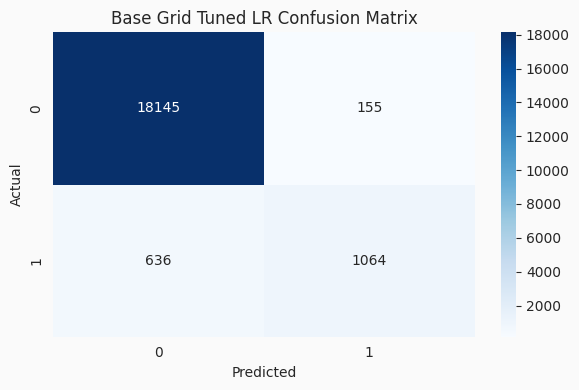

___________________________________________________________________________
Feature Selcted Grid Tuned LR
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.87      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Recall : 0.6294117647058823


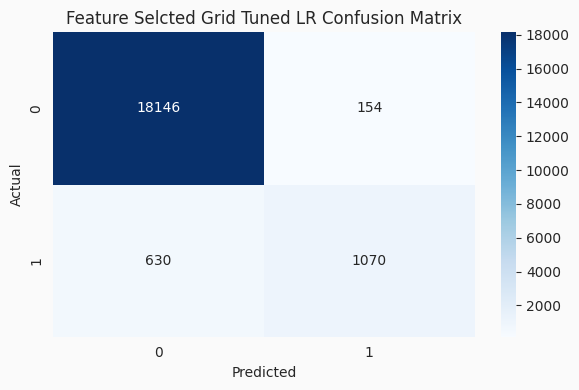

___________________________________________________________________________
Base Grid Tuned rf
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.98      0.68      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.68


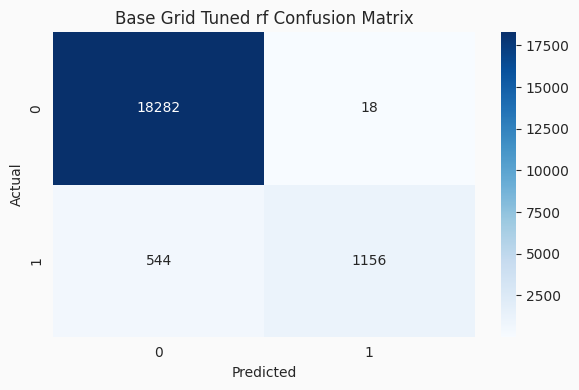

___________________________________________________________________________
Feature Selcted Grid Tuned RF
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.90      0.70      0.79      1700

    accuracy                           0.97     20000
   macro avg       0.94      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6988235294117647


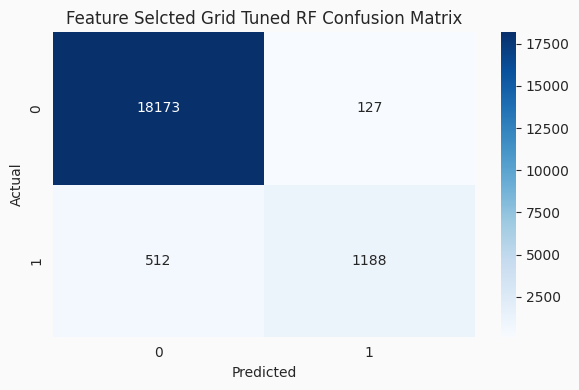

___________________________________________________________________________
Base Grid Tuned XGB
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.96      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.69


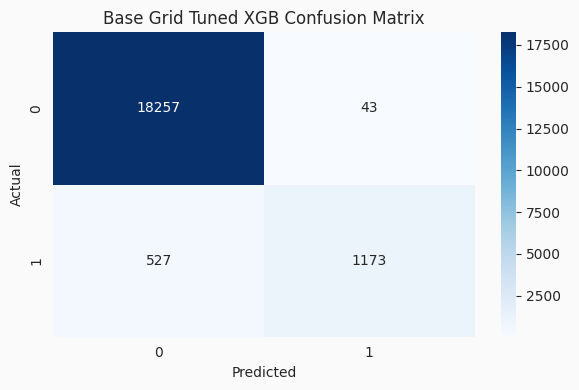

___________________________________________________________________________
Feature Selcted Grid Tuned XGB
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.97      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6858823529411765


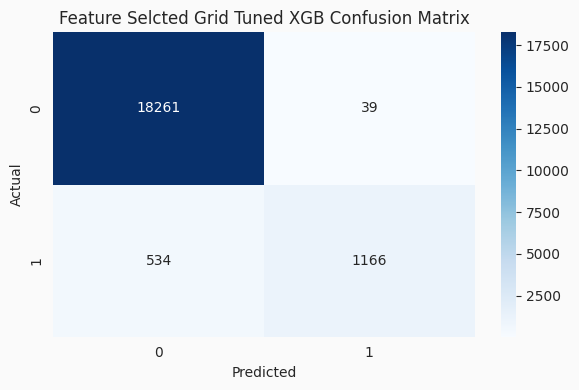

___________________________________________________________________________


In [ ]:
for model_name, model in grid_search_cv_models.items():
  print(model_name)
  print('_'*75)
  basic_scores(X_validation, y_validation, model, model_name)
  print('_'*75)

Feature Selected Fine Tuned LR
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.87      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Recall : 0.63


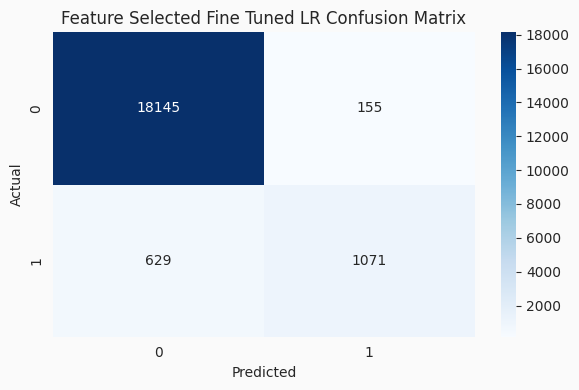

___________________________________________________________________________
Feature Selected Fine Tuned RF
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.90      0.70      0.79      1700

    accuracy                           0.97     20000
   macro avg       0.94      0.84      0.88     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6952941176470588


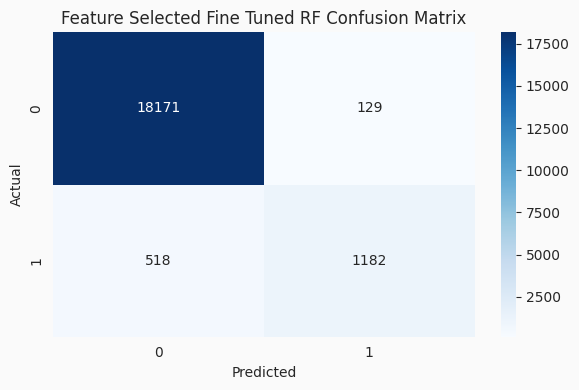

___________________________________________________________________________
Feature Selected Fine Tuned XGB
___________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.70      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000

Recall : 0.6976470588235294


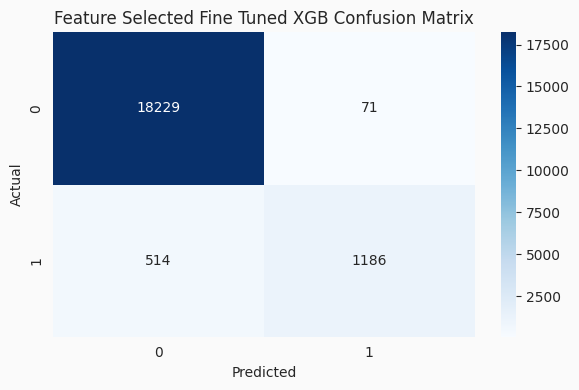

___________________________________________________________________________


In [ ]:
for model_name, model in random_search_cv_selected_models.items():
  print(model_name)
  print('_'*75)
  basic_scores(X_validation, y_validation, model, model_name)
  print('_'*75)

### Cross-Validation

In [ ]:
cv_fine_tuned_selected_collection = cross_val_collector(random_search_cv_selected_models , X_train_base, y_train_base)

Feature Selected Fine Tuned LR
AVG CV f1_macro : 0.8577154240949888 
Feature Selected Fine Tuned RF
AVG CV f1_macro : 0.8834502326756691 
Feature Selected Fine Tuned XGB
AVG CV f1_macro : 0.89298573392711 


## RQ 5 : Overall and Significance
##### Overall Comparison Reveals:

- Balanced XGB has highest f1  
  - Balancing may work. *P-value testing was needed*.   
- **XGB outperforms most models**  
- **Clear pattern of tree-based models outperforming linear models**

#### Significance Testing

**The linear/tree split is significant**: \~0.067 difference

**Base/tuned split shows no significant difference**: \~0.022.   
The model comparison box-plot supports this, showing no performance bias by processing group.    

#### Conclusion

Greater differences are due to model type rather than engineering.

#### Full Model CV Comparison

In [ ]:
all_collections_list_f1 = [cv_base_collection , cv_selected_collection , cv_balenced_collection, cv_fine_tuned_selected_collection]

In [ ]:
lin_group = []
tree_group = []
all_scores = []

#Loop through collections print scores and partition for analysis
for collection in all_collections_list_f1:
  for model_name, score in collection.items():
    cv_score = np.mean(score)
    all_scores.append(((model_name), (cv_score)))
    #Get linear scores
    if any(x in model_name.lower() for x in ['lr', 'svc']):
      lin_group.append(((model_name), (score)))
    #Get tree scores
    if any(x in model_name.lower() for x in ['rf', 'xgb']):
      tree_group.append(((model_name), (score)))

all_for_display = sorted(all_scores, key=lambda x: x[1], reverse = True)


In [ ]:
for i, model in enumerate(all_for_display):
  print(f'{i}: {model[0]} -> f1_macro = {model[1]:.2f}')

0: Balenced XGB -> f1_macro = 0.89
1: Feature Selected Fine Tuned XGB -> f1_macro = 0.89
2: Base Random Forest -> f1_macro = 0.89
3: Base XGB Classifier -> f1_macro = 0.89
4: Feature Selected XGB -> f1_macro = 0.89
5: Balenced Random Forest -> f1_macro = 0.89
6: Feature Selected Rf -> f1_macro = 0.88
7: Feature Selected Fine Tuned RF -> f1_macro = 0.88
8: Base SVC No-balenced -> f1_macro = 0.86
9: Feature Selected Fine Tuned LR -> f1_macro = 0.86
10: Feature Selected LR -> f1_macro = 0.86
11: Base LR Scaled -> f1_macro = 0.86
12: Balenced SVC -> f1_macro = 0.82
13: Base SVC -> f1_macro = 0.78
14: Balenced Logistic Regression -> f1_macro = 0.75
15: Feature Selected SVC -> f1_macro = 0.72


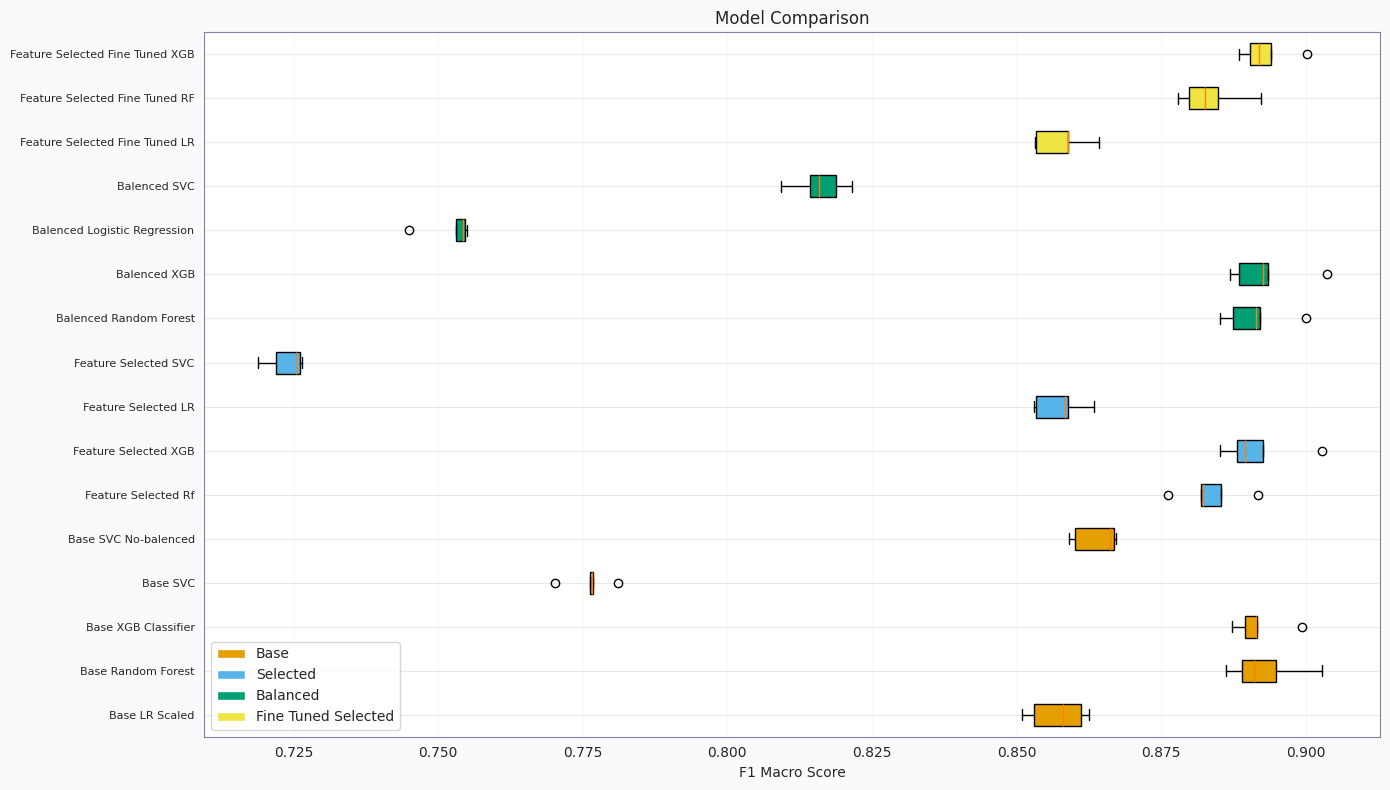

In [ ]:
fig, ax = plt.subplots(figsize=(14, max(8, len(all_scores) * 0.35)))

labels = list(all_scores.keys())
scores = [all_scores[k] for k in labels]

# Shorten labels: remove collection prefix, keep just model name
short_labels = [label.split(' - ')[-1] if ' - ' in label else label for label in labels]

# Horizontal boxplot for readability with many models
bp = ax.boxplot(scores, vert=False, patch_artist=True)

# Color by collection using Okabe-Ito
colors_map = {
    'Base': okabe_Ito_palette[0],
    'Selected': okabe_Ito_palette[1],
    'Balanced': okabe_Ito_palette[2],
    'Fine Tuned Selected': okabe_Ito_palette[3]
}
#okabe_Ito_palette
for i, label in enumerate(labels):
    for coll_name, color in colors_map.items():
        if label.startswith(coll_name):
            bp['boxes'][i].set_facecolor(color)
            break

ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('F1 Macro Score')
ax.set_title('Model Comparison')
ax.grid(True, axis='x', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color, label=name) for name, color in colors_map.items()]
ax.legend(handles=legend_handles, loc='lower left')

plt.tight_layout()
plt.show()

#### Significance Tests: Tree vs Linear

In [ ]:
lin_vals = [score[1] for score in lin_group ]
tree_vals = [score[1] for score in tree_group ]

#Adapted haixia's code with help of claude.ai
from scipy.stats import ttest_ind

#Flatten the CV scores from each group
lin_flat = np.concatenate(lin_vals)
tree_flat = np.concatenate(tree_vals)
lin_flat = lin_flat[~np.isnan(lin_flat)] #Imputing makes no sense, as it would falsify a model's score
tree_flat = tree_flat[~np.isnan(tree_flat)] # Sometimes, depending on cv used for test, nan values appear
#Significance testing
t_stat, p_value = ttest_ind(lin_flat, tree_flat)
print('For Linear vs Tree-based models:')
#Stolen again, from haixia
if p_value < 0.05:
    print("The difference between the models is statistically significant.")
else:
    print("No significant difference between the models.")

print(f'Linear Models f1_macro Avg : {np.mean(lin_flat):.3f}')
print(f'Tree-Based Models f1_macro Avg : {np.mean(tree_flat):.3f}')

For Linear vs Tree-based models:
The difference between the models is statistically significant.
Linear Models f1_macro Avg : 0.822
Tree-Based Models f1_macro Avg : 0.889


#### Significance Test: Base vs Fine Tuned and Feature Selected

In [ ]:
base_flat = np.concatenate(list(cv_base_collection.values()))
fine_tuned_flat = np.concatenate(list(cv_fine_tuned_selected_collection.values()))

fine_tuned_flat = fine_tuned_flat[~np.isnan(fine_tuned_flat)]
base_flat = base_flat[~np.isnan(base_flat)]

In [ ]:
t_stat_2, p_value_2 = ttest_ind(base_flat, fine_tuned_flat)
print('For Base vs Tuned models:')
#Stolen again, from haixia
if p_value_2 < 0.05:
    print("The difference between the groups is statistically significant.")
else:
    print("No significant difference between the groups.")

print(f'Base Models f1_macro Avg : {np.mean(base_flat):.3f}')
print(f'Tuned Feature Selected Models f1_macro Avg : {np.mean(fine_tuned_flat):.3f}')

For Base vs Tuned models:
No significant difference between the groups.
Base Models f1_macro Avg : 0.856
Tuned Feature Selected Models f1_macro Avg : 0.878


## RQ 6 : Final Analysis on Test Set
The tuned and balanced results on unseen test data show some interesting deviations from the previous tests, though it should be noted that the results represent a single round of prediction.

#### Results

- **Linear models performed well**   
- SVC has adapted better than all other models   
- Possibly, tree-based models were overfitting  
- All models well represented in ROC/AUC graph   
- Does not represent random guessing (Chan, 2018).

**Though the data is likely synthetic, it has been generated in such a way as to be predictable.**

In [ ]:
''' INITIALISE MULTIPLE LISTS FOR PREDICTION ON TEST-DATA '''
#Random Forest
#f1
f1_mac_tuned_rf = []
f1_mac_base_rf = []
f1_mac_balenced_rf = []
#recall
recall_tuned_rf = []
recall_base_rf = []
recall_balenced_rf = []

#XGB
#f1
f1_mac_tuned_xgb = []
f1_mac_base_xgb = []
f1_mac_balenced_xgb = []
#recall
recall_tuned_xgb = []
recall_base_xgb = []
recall_balenced_xgb = []

#linear Reg
#f1
f1_mac_tuned_lr = []
f1_mac_base_lr = []
f1_mac_balenced_lr = []
#recall
recall_tuned_lr = []
recall_base_lr = []
recall_balenced_lr = []

#Svc
#f1
f1_mac_selected_svc = []
f1_mac_base_svc = []
f1_mac_balenced_svc = []
#recall
recall_selected_svc = []
recall_base_svc = []
recall_balenced_svc = []

#Probs for ROC/AUC -> top 3 and bottom 3
probs_balenced_xgb = []
probs_selected_tuned_xgb = []
probs_base_rf = []

probs_base_svc = []
probs_balenced_lr = []
probs_selected_svc = []



In [ ]:
'''#TOP 3, BOTTOM 3
0: Balenced XGB -> f1_macro = 0.89
1: Feature Selected Fine Tuned XGB -> f1_macro = 0.89
2: Base Random Forest -> f1_macro = 0.89

13: Base SVC -> f1_macro = 0.78
14: Balenced Logistic Regression -> f1_macro = 0.75
15: Feature Selected SVC -> f1_macro = 0.72
'''

In [ ]:
'''Predictions'''
#BASE SCORES REMOVED DUE TO LAST MINUTE ISSUES WITH TEST SET SHAPE. SORRY!
#rf
y_pred_test_fine_tuned_rf = random_search_rf_selected.best_estimator_.predict(X_test)
#y_pred_base_rf = base_rf_pipe.predict(X_test)
y_pred_balenced_rf =  base_balenced_rf_pipe.predict(X_test)

#xgb
y_pred_test_fine_tuned_xgb = random_search_xgb_selected.best_estimator_.predict(X_test)
#y_pred_base_xgb = base_xgb_pipe.predict(X_test)
y_pred_balenced_xgb = base_balenced_xgb_pipe.predict(X_test)

#lr
y_pred_test_fine_tuned_lr = random_search_lr_selected.best_estimator_.predict(X_test)
#y_pred_base_lr = base_lr_pipe_with_scaling.predict(X_test)
y_pred_balenced_lr = base_balenced_lr_pipe.predict(X_test)


#svc
y_pred_selected_svc = selected_svc_pipe.predict(X_test)
#y_pred_base_svc = base_svc.predict(X_test)
y_pred_balenced_svc = base_balenced_svc_pipe.predict(X_test)

'''Score F1'''
#rf
f1_mac_tuned_rf.append(f1_score(y_test, y_pred_test_fine_tuned_rf, average='macro'))
#f1_mac_base_rf.append(f1_score(y_test, y_pred_base_rf, average='macro'))
f1_mac_balenced_rf.append(f1_score(y_test, y_pred_balenced_rf, average='macro'))

#xgb
f1_mac_tuned_xgb.append(f1_score(y_test, y_pred_test_fine_tuned_xgb, average='macro'))
#f1_mac_base_xgb.append(f1_score(y_test, y_pred_base_xgb, average='macro'))
f1_mac_balenced_xgb.append(f1_score(y_test, y_pred_balenced_xgb, average='macro'))

#lr
f1_mac_tuned_lr.append(f1_score(y_test, y_pred_test_fine_tuned_lr, average='macro'))
#f1_mac_base_lr.append(f1_score(y_test, y_pred_base_lr, average='macro'))
f1_mac_balenced_lr.append(f1_score(y_test, y_pred_balenced_lr, average='macro'))

#svc
f1_mac_selected_svc.append(f1_score(y_test, y_pred_selected_svc, average='macro'))
#f1_mac_base_svc.append(f1_score(y_test, y_pred_base_svc, average='macro'))
f1_mac_balenced_svc.append(f1_score(y_test, y_pred_balenced_svc, average='macro'))

'''Score recall'''
#rf
recall_tuned_rf.append(recall_score(y_test, y_pred_test_fine_tuned_rf))
#recall_base_rf.append(recall_score(y_test, y_pred_base_rf))
recall_balenced_rf.append(recall_score(y_test, y_pred_balenced_rf ))

#xgb
recall_tuned_xgb.append(recall_score(y_test, y_pred_test_fine_tuned_xgb))
#recall_base_xgb.append(recall_score(y_test, y_pred_base_xgb))
recall_balenced_xgb.append(recall_score(y_test, y_pred_balenced_xgb ))

#lr
recall_tuned_lr.append(recall_score(y_test, y_pred_test_fine_tuned_lr))
#recall_base_lr.append(recall_score(y_test, y_pred_base_lr))
recall_balenced_lr.append(recall_score(y_test, y_pred_balenced_lr ))

#svc
recall_selected_svc.append(recall_score(y_test, y_pred_selected_svc))
#recall_base_svc.append(recall_score(y_test, y_pred_base_svc))
recall_balenced_svc.append(recall_score(y_test, y_pred_balenced_svc ))





In [ ]:
'''Probabilities for roc/auc'''
#ROC/AUC needs probability to show model confidnce that a sample is positive.
#*Code generated by claude.ai
probs_balenced_xgb = base_balenced_xgb_pipe.predict_proba(X_test)[:, 1]
probs_selected_tuned_xgb = random_search_xgb_selected.best_estimator_.predict_proba(X_test)[:, 1]
#probs_base_rf = base_rf_pipe.predict_proba(X_test)[:, 1]

probs_balenced_lr = base_balenced_lr_pipe.predict_proba(X_test)[:, 1]
#probs_base_svc = base_svc.decision_function(X_test)
probs_selected_svc = selected_svc_pipe.decision_function(X_test)

In [ ]:
#Group scores based on model nd engeering type
model_scores = {
    'Random Forest': {
        'Tuned': {'F1': f1_mac_tuned_rf, 'Recall': recall_tuned_rf},
        #'Base': {'F1': f1_mac_base_rf, 'Recall': recall_base_rf},
        'Balanced': {'F1': f1_mac_balenced_rf, 'Recall': recall_balenced_rf}
    },
    'XGBoost': {
        'Tuned': {'F1': f1_mac_tuned_xgb, 'Recall': recall_tuned_xgb},
        #'Base': {'F1': f1_mac_base_xgb, 'Recall': recall_base_xgb},
        'Balanced': {'F1': f1_mac_balenced_xgb, 'Recall': recall_balenced_xgb}
    },
    'Logistic Regression': {
        'Tuned': {'F1': f1_mac_tuned_lr, 'Recall': recall_tuned_lr},
        #'Base': {'F1': f1_mac_base_lr, 'Recall': recall_base_lr},
        'Balanced': {'F1': f1_mac_balenced_lr, 'Recall': recall_balenced_lr}
    },
    'SVC': {
        'Selected': {'F1': f1_mac_selected_svc, 'Recall': recall_selected_svc},
        #'Base': {'F1': f1_mac_base_svc, 'Recall': recall_base_svc},
        'Balanced': {'F1': f1_mac_balenced_svc, 'Recall': recall_balenced_svc}
    }
}

In [ ]:
#Display final scores
for model, variants in model_scores.items():
    print(f"\n{model}")
    print("=" * 40)
    for variant, metrics in variants.items():
        print(f"  {variant}:")
        print(f"    F1: {np.mean(metrics['F1']):.3f}")
        print(f"    Recall: {np.mean(metrics['Recall']):.3f}")


Random Forest
  Tuned:
    F1: 0.886
    Recall: 0.698
  Balanced:
    F1: 0.892
    Recall: 0.688

XGBoost
  Tuned:
    F1: 0.895
    Recall: 0.699
  Balanced:
    F1: 0.892
    Recall: 0.695

Logistic Regression
  Tuned:
    F1: 0.860
    Recall: 0.636
  Balanced:
    F1: 0.752
    Recall: 0.885

SVC
  Selected:
    F1: 0.719
    Recall: 0.919
  Balanced:
    F1: 0.819
    Recall: 0.791


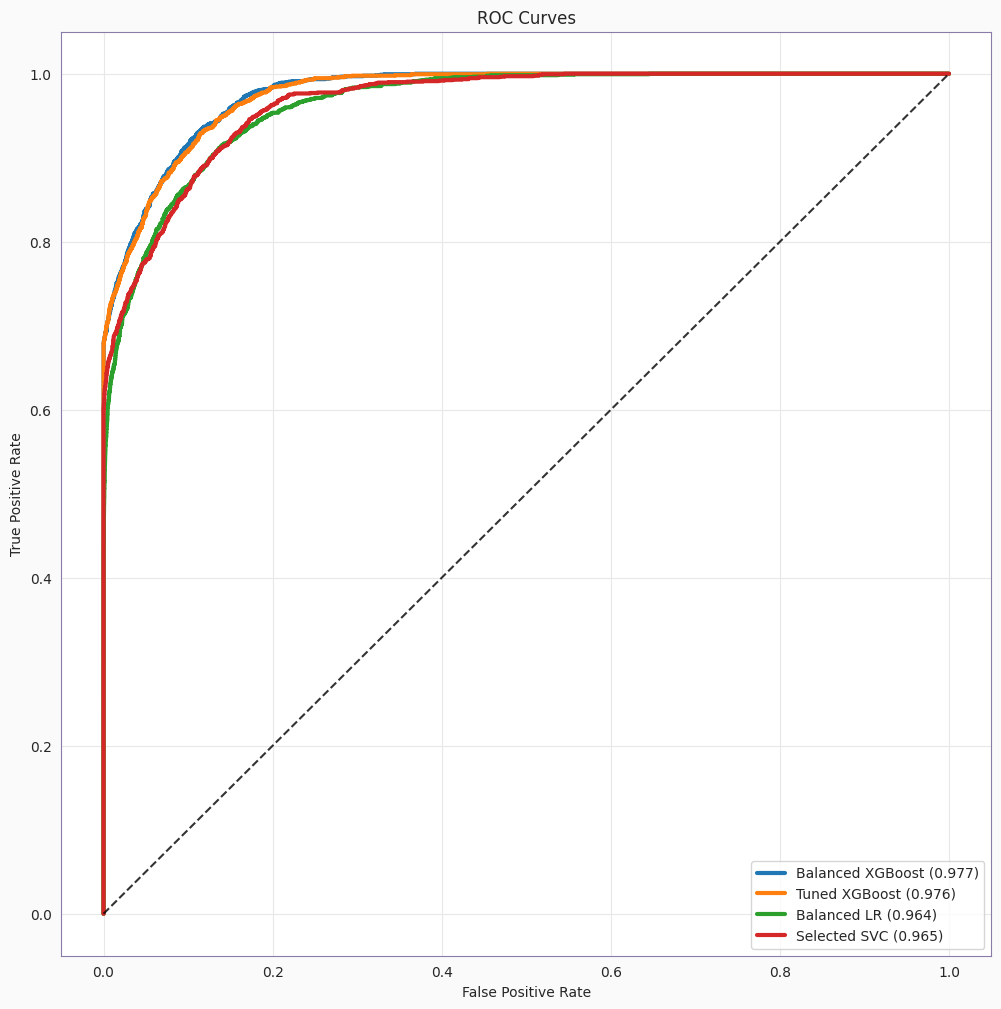

In [ ]:
#Code from claude.ai
#Roc/Auc Curves
probs_dict = {
    'Balanced XGBoost': probs_balenced_xgb,
    'Tuned XGBoost': probs_selected_tuned_xgb,
    #'Base Random Forest': probs_base_rf,
    'Balanced LR': probs_balenced_lr,
    #'Base SVC': probs_base_svc,
    'Selected SVC': probs_selected_svc
}

plt.figure(figsize=(12, 12))

for name, probs in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} ({roc_auc:.3f})', linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', alpha= 0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

## RQ 7 : Recall Set Experiment

##### Methodology

1\. Train on non-overly-fitted model.    
2\. Identify false negatives during validation, relabel as the third target class and add them back to the training data   
3\. Retrain on three class dataset.

### Results

- The umap shows FNs are within wider groups, not distinct  
- **Confusion matrices show failure to identify third class**

#### Conclusion

No significant findings were found.

In [ ]:
#all umap code from claude
import umap

In [ ]:
#Create base pipe for VISUALISATION
xgb_exp_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('model', XGBClassifier(eval_metric='logloss', random_state=SEED ))
])
xgb_exp_pipe.fit(X_train_base, y_train_base)
y_pred =  xgb_exp_pipe.predict(X_validation)#Provided by claude.ai
# Create labels for the four outcome types
outcome_labels = np.empty(len(y_test), dtype=object)
outcome_labels[(y_validation == 1) & (y_pred == 1)] = 'True Positive'
outcome_labels[(y_validation == 0) & (y_pred == 0)] = 'True Negative'
outcome_labels[(y_validation == 0) & (y_pred == 1)] = 'False Positive'
outcome_labels[(y_validation == 1) & (y_pred == 0)] = 'False Negative'

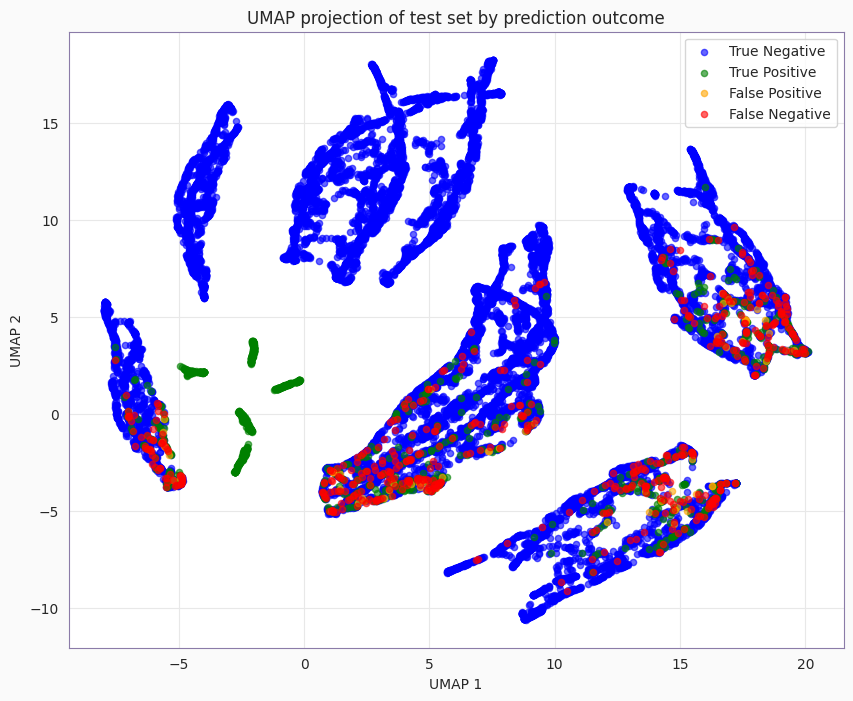

In [ ]:
#Mostly code from claude.ai
#Fit UMAP
# Select only numeric columns for visualization / easy to implement but possibly wrong
X_numeric = X_validation.select_dtypes(include=[np.number])
#Reduce dimentions
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_numeric)

# Plot
colors = {
    'True Positive': 'green',
    'True Negative': 'blue',
    'False Positive': 'orange',
    'False Negative': 'red'
}

plt.figure(figsize=(10, 8))
for label in ['True Negative', 'True Positive', 'False Positive', 'False Negative']:
    mask = outcome_labels == label
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                c=colors[label], label=label, alpha=0.6, s=20)

plt.legend()
plt.title('UMAP projection of test set by prediction outcome')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

In [ ]:
def basic_scores_multi(X_validation, y_validation, pipe, model_name):#Claude.ai re-wrote this
    y_pred = pipe.predict(X_validation)

    # classification_report already handles multiclass automatically
    print(classification_report(y_validation, y_pred))

    # For multiclass, specify average method
    print(f"Recall (macro): {recall_score(y_validation, y_pred, average='macro')}")
    print(f"Recall (weighted): {recall_score(y_validation, y_pred, average='weighted')}")

    # Optionally, show per-class recall
    recall_per_class = recall_score(y_validation, y_pred, average=None)
    for i, recall in enumerate(recall_per_class):
        print(f"Recall for class {i}: {recall:.3f}")

    plot_confusion_matrix(y_validation, y_pred, model_name=model_name)

In [ ]:
X_exp = X.copy()#Copy so as to avoid cross-contamination
y_exp = y.copy()

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     54900
           1       0.94      0.70      0.80      5100

    accuracy                           0.97     60000
   macro avg       0.96      0.85      0.89     60000
weighted avg       0.97      0.97      0.97     60000

Recall : 0.6958823529411765


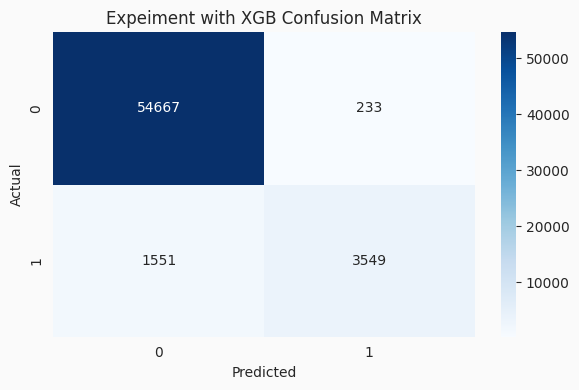

In [ ]:
#TRAIN NEW MODEL
X_exp_forclf, X_exp_nonclf, y_exp_forclf, y_exp_nonclf = train_test_split( X_exp, y_exp, test_size=0.6, random_state=SEED, stratify=y_exp)
exp_clf_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('model', XGBClassifier(eval_metric='logloss', random_state=SEED ))
])


exp_clf_pipe.fit(X_exp_forclf, y_exp_forclf)
y_pred_exp = exp_clf_pipe.predict(X_exp_nonclf)
basic_scores(X_exp_nonclf, y_exp_nonclf, exp_clf_pipe, 'Expeiment with XGB')

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     10980
           1       0.99      0.97      0.98       710
           2       0.21      0.02      0.04       310

    accuracy                           0.97     12000
   macro avg       0.72      0.66      0.67     12000
weighted avg       0.95      0.97      0.96     12000

Recall (macro): 0.6620151959409077
Recall (weighted): 0.97025
Recall for class 0: 0.997
Recall for class 1: 0.966
Recall for class 2: 0.023


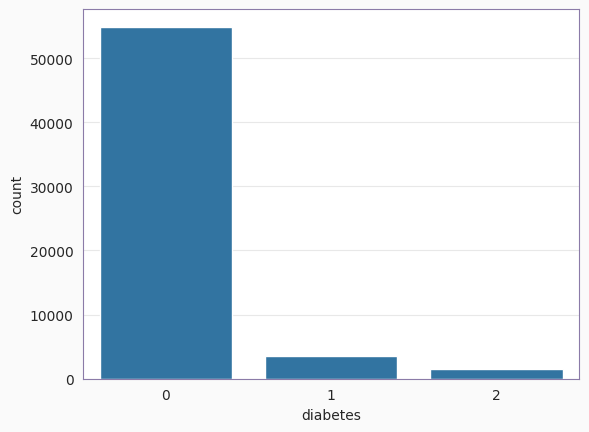

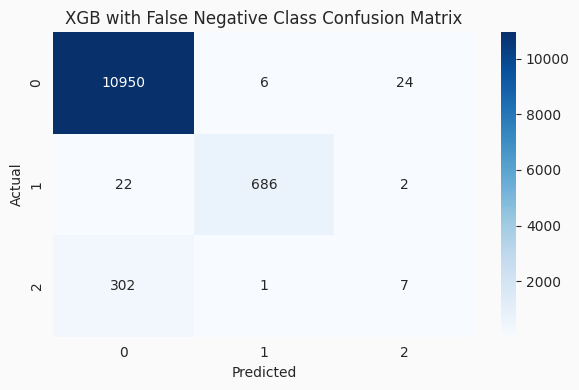

In [ ]:
X_to_label = X_exp_nonclf.copy()#Claude helped re-arrange for test data
y_to_label = y_exp_nonclf.copy()
# Isolate False Negatives
false_negatve_mask = (y_exp_nonclf == 1) & (y_pred_exp == 0)
y_to_label[false_negatve_mask] = 2

sns.countplot(x=y_to_label)
#TRAIN TRI-CLASS MODEL!
X_label_train, X_label_test, y_label_train, y_label_test = train_test_split( X_to_label, y_to_label, test_size=0.2, random_state=SEED, stratify=y_to_label)
new_class_pipe = Pipeline([
    ('preprocessor', preprocessing_base_no_scale_with_cat),
    ('model', XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='logloss', random_state=SEED ))
])
new_class_pipe.fit(X_label_train, y_label_train)
basic_scores_multi(X_label_test, y_label_test, new_class_pipe, 'XGB with False Negative Class')

## Reflection

- In future I will build a working framework of both code and written elements to use throughout.   
- There were too many RQs and models.

I enjoyed working with pipelines and feel that I elicited tangible results from a few of my research questions.

***Word Count \- 2170***

## References

Accu-Chek UK & Ireland (2023) HbA1c Calculator | Accu-Chek UK & Ireland www.accu-chek.co.uk. 12 December 2023 [online]. Available from: https://www.accu-chek.co.uk/tools/hba1c-calculator [Accessed 29 November 2025].

Balkau, B. et al. (2008) Predicting Diabetes: Clinical, Biological, and Genetic Approaches: Data from the Epidemiological Study on the Insulin Resistance Syndrome (DESIR). Diabetes Care [online]. 31 (10), pp. 2056–2061. [Accessed 25 November 2025].

British Heart Foundation (2022) Why Should I Know My Blood Sugar levels? www.bhf.org.uk. 2022 [online]. Available from: https://www.bhf.org.uk/informationsupport/heart-matters-magazine/medical/tests/blood-sugar [Accessed 25 November 2025].

Brownlee, J. (2019) Tune Hyperparameters for Classification Machine Learning Algorithms Machine Learning Mastery. 12 December 2019 [online]. Available from: https://machinelearningmastery.com/hyperparameters-for-classification-machine-learning-algorithms/ [Accessed 17 November 2025].

Chan, C. (2018) What is a ROC Curve and How to Interpret It Displayr. 5 July 2018 [online]. Available from: https://www.displayr.com/what-is-a-roc-curve-how-to-interpret-it/ [Accessed 10 December 2025].

Chugani, V. (2024) One Hot Encoding: Understanding the 'Hot' in Data - MachineLearningMastery.com MachineLearningMastery.com. 18 August 2024 [online]. Available from: https://machinelearningmastery.com/one-hot-encoding-understanding-the-hot-in-data/ [Accessed 10 December 2025].

Egan, A.M. and Dinneen, S.F. (2019) What is diabetes? Medicine [online]. 47 (1), pp. 1–4. Available from: https://www.sciencedirect.com/science/article/pii/S1357303918302627 [Accessed 25 November 2025].

Gonzales, A., Guruswamy, G. and Smith, S.R. (2023) Synthetic data in health care: A narrative review. Johnson, A., ed. PLOS Digital Health [online]. 2 (1), p. e0000082.

K.M. Venkat Narayan, Williams, D., Gregg, E.W. and Cowie, C.C. (2011) Diabetes Public Health 1st edition. Oxford University Press.

Laerd Statistics (2020) Pearson Product-Moment Correlation Laerd Statistics. 2020 [online]. Available from: https://statistics.laerd.com/statistical-guides/pearson-correlation-coefficient-statistical-guide.php [Accessed 28 November 2025].

Laerd Statistics (2018) Spearman's Rank-Order Correlation Laerd Statistics. 2018 [online]. Available from: https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php [Accessed 28 November 2025].

Liu, H. (no date) pipe-scaling-randsearch-ttest.py Python File.

MedlinePlus (2017) Aging changes in body shape: MedlinePlus Medical Encyclopedia Medlineplus.gov. 2017 [online]. Available from: https://medlineplus.gov/ency/article/003998.htm [Accessed 28 November 2025].

NHS (2024) High Blood Pressure NHS. 19 July 2024 [online]. Available from: https://www.nhs.uk/conditions/high-blood-pressure/ [Accessed 25 November 2025].

NHS (2023) Diagnosis - Obesity NHS. 2023 [online]. Available from: https://www.nhs.uk/conditions/obesity/diagnosis/ [Accessed 29 November 2025].

NHS Gloucestershire Hospitals (2015) Haemoglobin A1c (HbA1c) Gloucestershire Hospitals NHS Foundation Trust. 2015 [online]. Available from: https://www.gloshospitals.nhs.uk/our-services/services-we-offer/pathology/tests-and-investigations/haemoglobin-a1c-hba1c/ [Accessed 25 November 2025].

Panchal, C. (2024) HbA1c Conversion Chart Organising Chaos. 3 February 2024 [online]. Available from: https://organising-chaos.com/blogs/news/hba1c-conversion-chart?srsltid=AfmBOoqM9YArtaTK6fRuBMWLT9gHL-AUxmOC_lYNXYAf1uRy0MV2SENG [Accessed 29 November 2025].

Pandas (2025) pandas.DataFrame.corr — pandas 1.3.2 documentation pandas.pydata.org. 2025 [online]. Available from: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html [Accessed 28 November 2025].

Raschka, S., Liu, Y. (Hayden), Mirjalili, V. and Dzhulgakov, D. (2022) Machine Learning with Pytorch and Scikit-Learn : Develop Machine Learning and Deep Learning Models with Python 1st edition. Birmingham, Packt Publishing, Limited, pp. 60, 77, 86, 95–96.

Russell, S.J. and Norvig, P. (2020) Artificial Intelligence: a Modern Approach 4th edition. Upper Saddle River, Pearson, p. 684.

Scikit-learn Developers (2025a) 10. Common pitfalls and recommended practices scikit-learn. 2025 [online]. Available from: https://scikit-learn.org/stable/common_pitfalls.html [Accessed 24 November 2025].

Scikit-learn Developers (2025b) sklearn.preprocessing.MultiLabelBinarizer — scikit-learn 0.23.1 documentation scikit-learn.org. 2025 [online]. Available from: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html [Accessed 27 November 2025].

Scikit-learn Developers (2019) sklearn.svm.SVC — scikit-learn 0.22 documentation Scikit-learn.org. 2019 [online]. Available from: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html [Accessed 10 December 2025].

Scikit-learn Developers (2025c) SMOTE — Version 0.9.0 imbalanced-learn.org. 2025 [online]. Available from: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html [Accessed 10 December 2025].

Selph (2023) Blood Sugar Level Chart Selph.co.uk. 2023 [online]. Available from: https://www.selph.co.uk/learn/metabolic-health/blood-sugar/blood-sugar-chart [Accessed 29 November 2025].

Surampudi, S. (2020) About Unstructured Text Oracle Help Center. 10 November 2020 [online]. Available from: https://docs.oracle.com/en/database/oracle/oracle-database/18/dmprg/unstructured-text.html [Accessed 25 November 2025].

USA Facts Team (2023) What percentage of the US population is transgender? USAFacts. 3 August 2023 [online]. Available from: https://usafacts.org/articles/what-percentage-of-the-us-population-is-transgender/ [Accessed 28 November 2025].

xgboost developers (2022) Introduction to boosted trees — xgboost 1.5.1 documentation xgboost.readthedocs.io. 2022 [online]. Available from: https://xgboost.readthedocs.io/en/stable/tutorials/model.html [Accessed 10 December 2025].

Yoshizawa, T., Ishikawa, K., Nagasawa, H., Takeuchi, I., Kei Jitsuiki, Omori, K., Hiromichi Ohsaka and Yanagawa, Y. (2018) A Fatal Case of Super-super Obesity (BMI >80) in a Patient with a Necrotic Soft Tissue Infection. Internal Medicine Journal [online]. 57 (10). Available from: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5995720/ [Accessed 5 June 2023].

Ziya (2025) Diabetes Clinical Dataset(100k rows) Kaggle.com. 2025 [online]. Available from: https://www.kaggle.com/datasets/ziya07/diabetes-clinical-dataset100k-rows [Accessed 1 October 2025].

## APPENDIX
### A. List of Claude.ai conversations used in this project.


1. **https://claude.ai/chat/df7baf88-ab78-4f76-b134-0cf12e008a7b** — EDA and ML algorithm comparison (Oct 30)
   - Model comparison functions, cross-validation scoring, confusion matrices, ROC curves

2. **https://claude.ai/chat/54ce41b9-b4e6-448f-81ff-abefc403195d** — Cross-validation and GridSearchCV (Nov 8)
   - Building cross_val_score functions, GridSearchCV implementation, hyperparameter tuning, fixing code issues with model comparison

3. **https://claude.ai/chat/9b5357da-7ef3-44c5-9126-8ed9440b44ea** — Data leakage and train/test splitting (Nov 2)
   - Proper feature engineering order, references to scikit-learn documentation on avoiding data leakage

4. **https://claude.ai/chat/abe10b18-38ca-4752-976c-c7950a0df490** — Pipelines and statistical testing (Dec 10)
   - Integrating GridSearchCV into pipelines, t-tests and p-values for model comparison, StratifiedKFold, RandomizedSearchCV

5. **https://claude.ai/chat/c22639e0-4e7e-455e-a228-3ec3c9adde97** — Hyperparameter ranges and solvers (Dec 8)
   - Academic sources for hyperparameter tuning, solver explanations, specific parameter ranges for SVM/RF/XGBoost from papers

6. **https://claude.ai/chat/08c4736e-0319-4959-893a-422b02505337** — Classes vs functions for ML (Nov 13)
   - Discussion on when to use OOP vs functional approaches

7. **https://claude.ai/chat/baa63b80-5804-4703-bdd4-aee915fc1486** — Dataset exploration (Oct 22)
   - Working with the diabetes dataset, handling hidden missing values, synthetic data characteristics


